# Article 1: Effect of heterogenous emissivity field on thermal results during additive manufacturing process

## Set-up workspace

### Imports

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from brokenaxes import brokenaxes
from matplotlib.colors import LinearSegmentedColormap, Normalize
from pathlib import Path

# Set global error handling for NumPy
np.seterr(invalid='ignore', divide='ignore')
import scienceplots
plt.style.use(['science', 'grid'])

from TherMIFASOL.core.variables.GlobalVariables import (
    LINES_CRED, COLUMNS_CRED, FAC, T_SOLIDUS, T_LIQUIDUS, CET_IN718_fitting_parameters
)
from TherMIFASOL.core.variables.BoardCardFilterVariable import (
    params_clip, boundaries_data_selection, time_constant_parameters,
    params_first_order, boundaries_data_color, colors_plots_cordon
)
from TherMIFASOL.core.data_processing.PYROMETER_functions import (
    collect_data_pyrometer
)
from TherMIFASOL.core.data_processing.CRED_functions import (
    load_cred_array, dl_to_thermo
)
from TherMIFASOL.core.models.EmissivityEmpiricalLaws import (
    first_order_emissivity, wagner_inspired_emissivity, mean_absolute_image_difference
)
from TherMIFASOL.core.models.ThermalGradientRegularized import (
    RegularizedThermalGradient
)
from TherMIFASOL.core.models.ThermalAnalysis import (
    hunt_data_on_isotherm, classify_growth_mode, display_hunt_criterion, display_G_and_R_on_images
)
from TherMIFASOL.core.utils.visualization import (
    setup_contour_parameters, plot_temperature_evolution, plot_thermal_images,
    create_csv_file, interpolate_color, interpolate_to_black, plot_differences
)
from TherMIFASOL.core.utils.ImageProcessing import (
    get_video_from_images
)


### Paths

In [2]:
PATH_DATA = "/media/dolle/Extreme SSD/DATA_MIFASOL/"
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[3]
except NameError:
    BASE_DIR = Path().resolve().parents[3]


# Path to data
#-------------------
data_path = os.path.join(
    PATH_DATA, "experiences/BoardCardFilter/DEC1/"
)


# Calibration tables
#-------------------

#   CRED:
array_nuc = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/NUC/NUC_2pts_Temp500__diaphMIN_bois2.npy"
        )
    )
array_calibration = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/FLUX/FLUX_IT100_deg1_diaphMIN_bois2_TRUSTWORTHY.npy"
        )
    )


# Saving path
#------------
saving_path = os.path.join(BASE_DIR, "results/article/")

## Pyrometer analysis

### Collecting data

#### Global data

In [3]:
list_beads:list = [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
full_time_history = []
full_time_temperature = []
full_time_emissivity = []

for id_bead in list_beads:
    path_data_bead:str = os.path.join(data_path, f"pyrometer/WLAM_H322_14150_{id_bead}.csv")
    dict_data_bead:dict = collect_data_pyrometer(csv_path=path_data_bead)
    
    bead_time = dict_data_bead['array absolute time']
    bead_temperature = dict_data_bead['array MAtemp2C']
    bead_emissivity = dict_data_bead['array MAemissivity']
    data_to_keep = bead_temperature > 552

    full_time_history += list(bead_time[data_to_keep])
    full_time_temperature += list(bead_temperature[data_to_keep])
    full_time_emissivity += list(bead_emissivity[data_to_keep])

full_time_history=np.asarray(full_time_history)
full_time_history-=full_time_history[0]

full_time_temperature=np.asarray(full_time_temperature)
full_time_emissivity=np.asarray(full_time_emissivity)

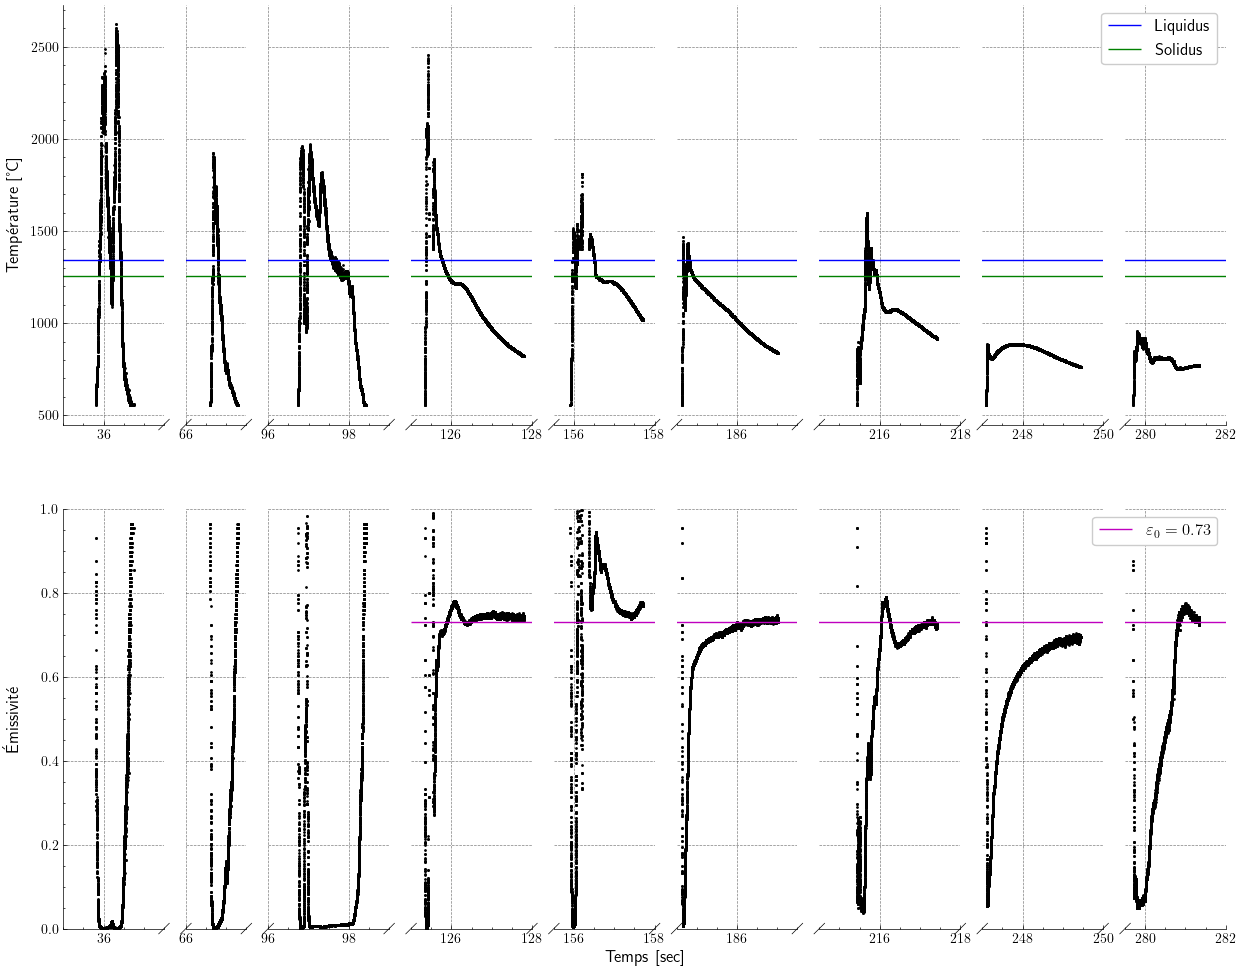

In [4]:
# plt.rcParams['font.family'] = 'serif'  # Options: 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'
# plt.rcParams['font.serif'] = 'Times New Roman'  # Specific font
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial']
})

fig = plt.figure(figsize=(15, 12))

# First sub-graph
bax1 = brokenaxes(
    xlims=((35, 37.5), (66, 67.5), (96, 99), (125, 128), (155.5, 158), (184.5, 187.5), (214.5, 218), (247, 250), (279.5, 282)),
    hspace=.1,
    subplot_spec=fig.add_gridspec(2, 1)[0],
    d=0.005
)
bax1.scatter(full_time_history, full_time_temperature, s=1, c='k')
bax1.hlines(
    y=T_LIQUIDUS-273.15, 
    xmin=full_time_history[0], 
    xmax=full_time_history[-1], 
    color="b", lw=1, label='Liquidus'
    )
bax1.hlines(
    y=T_SOLIDUS-273.15, 
    xmin=full_time_history[0], 
    xmax=full_time_history[-1], 
    color="g", lw=1, label='Solidus'
    )
# Second sub-graph
bax2 = brokenaxes(
    xlims=((35, 37.5), (66, 67.5), (96, 99), (125, 128), (155.5, 158), (184.5, 187.5), (214.5, 218), (247, 250), (279.5, 282)),
    hspace=.1,
    subplot_spec=fig.add_gridspec(2, 1)[1],
    d=0.005
)
bax2.scatter(full_time_history, full_time_emissivity, c='k', s=1)
bax2.hlines(
    y=0.73, 
    xmin=125, 
    xmax=full_time_history[-1], 
    color="m", lw=1, label=r'$\varepsilon_{0} = 0.73$'
    )


# Settings
bax1.set_ylabel('Température [°C]')
bax1.legend()
bax2.set_xlabel('Temps [sec]')
bax2.set_ylabel('Émissivité')
bax2.set_ylim(0, 1)
bax2.legend()

for ax in bax1.axs:
    ax.tick_params(axis='both', which='major', labelsize=10)
for ax in bax2.axs:
    ax.tick_params(axis='both', which='major', labelsize=10)


# Afficher le graphique
plt.show()


#### Local data

In [5]:
list_relevant_beads:list = [11, 12, 13, 14, 15, 16]
DATA:dict = {id_relevant_beads:{} for id_relevant_beads in list_relevant_beads}

for id_relevant_beads in list_relevant_beads:
    low_boundary, _ = boundaries_data_selection[id_relevant_beads]
    
    path_data_bead:str = os.path.join(data_path, f"pyrometer/WLAM_H322_14150_{id_relevant_beads}.csv")
    dict_data_bead:dict = collect_data_pyrometer(csv_path=path_data_bead)
   
    mask = dict_data_bead['array time'] > low_boundary

    DATA[id_relevant_beads]['array time'] = dict_data_bead['array time'][mask] - low_boundary
    DATA[id_relevant_beads]['array MAtemp2C'] = dict_data_bead['array MAtemp2C'][mask]
    DATA[id_relevant_beads]['array MAemissivity'] = dict_data_bead['array MAemissivity'][mask]

### First order law to fit

Black box that should take into consideration coupled phenomena (oxidation rate, argon flow, thermal gradients and state change)
- $\varepsilon(t, d) = \varepsilon_{non-oxy} + (\varepsilon_{oxy} - \varepsilon_{non-oxy})\left(1 - \exp\left(\displaystyle\frac{-(t-t_0)}{\tau(d)}\right)\right)$ avec $\varepsilon_{non-oxy} = 0.23$ et $\varepsilon_{oxy} = 0.73$



#### Use of the first order law

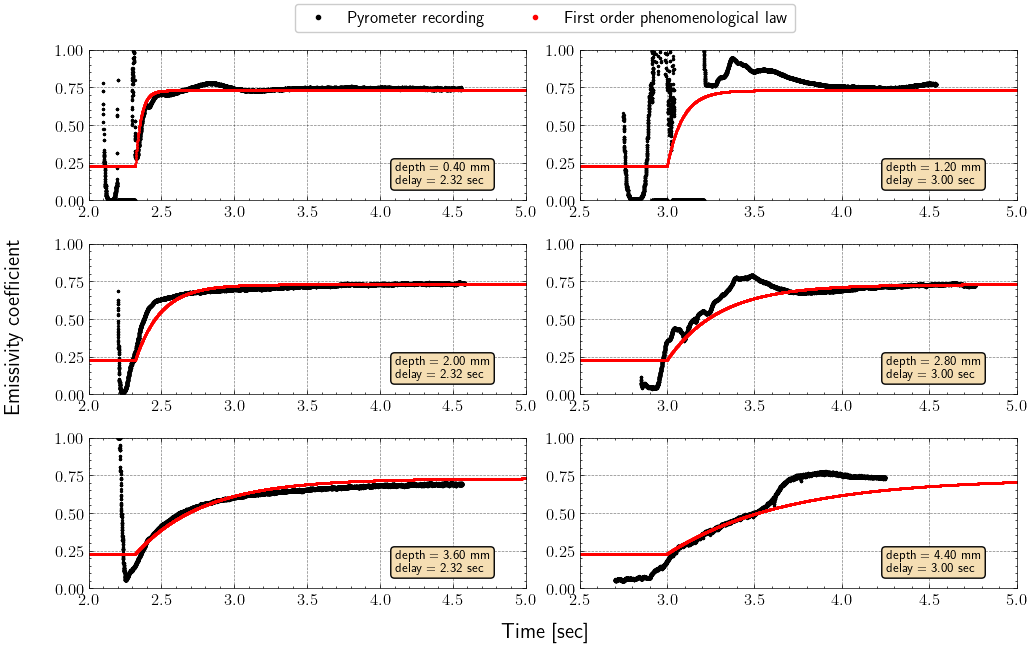

In [6]:
list_beads = [11, 12, 13, 14, 15, 16]

# Temperature for first order law plot's
fake_time = np.arange(0, 5, 0.001)

# Average depth of pyrometric recording regarding to top side of the on-manufacturing layer.
offset_depth = 0.4
x_full = np.asarray([i+offset_depth for i in np.arange(0, 4.8, 0.8)])
x_pixels = np.asarray(x_full/FAC + 255, dtype=int)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 6))
for idx, (px, cordon) in enumerate(zip(x_pixels, list_beads)):
    row, col = divmod(idx, 2)

    # Pyrometer data
    Raw_data_time_pyrometer = np.copy(DATA[cordon]['array time'])
    Raw_data_TwoColorTemperature_pyrometer = DATA[cordon]['array MAemissivity']

    # odd
    if cordon == 11:
        Raw_data_time_pyrometer+=2.1
    elif cordon ==13:
        Raw_data_time_pyrometer+=2.2
    elif cordon ==15:
        Raw_data_time_pyrometer+=2.2

    # even
    elif cordon ==12:
        Raw_data_time_pyrometer+=2.75
    elif cordon ==14:
        Raw_data_time_pyrometer+=2.85
    elif cordon ==16:
        Raw_data_time_pyrometer+=2.7

    # Phenomenological law
    depth = x_full[idx]
    delay = params_first_order[cordon]['delay']

    # Plot emissivity profile
    emissivity_profile = first_order_emissivity(
        time=fake_time, 
        depth=(px - 250)*FAC, # [mm]
        delay=delay,
        params_tau_evolve=time_constant_parameters,
        eps_non_oxy= 0.23,
        eps_oxy= 0.73
        )
    axes[row, col].scatter(Raw_data_time_pyrometer, Raw_data_TwoColorTemperature_pyrometer, label='Pyrometer', s=2, c='k')
    axes[row, col].scatter(fake_time, emissivity_profile, s=1, c='red', label='Camera: Wake pyrometer')
    axes[row, col].set_ylim(ymin=0, ymax=1)
    
    # Ajouter une annotation pour afficher les paramètres
    # annotation_text = r"$\tau$ = " +f"{tau:.2f}\ndelay = {delay:.2f}"
    annotation_text = r"depth = " +f"{depth:.2f} mm\ndelay = {delay:.2f} sec"
    axes[row, col].annotate(
        annotation_text, xy=(0.70, 0.25), xycoords='axes fraction',
        fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='wheat')
        )

    # axes[row, col].legend()
    if cordon % 2 == 0:
        # axes[row, col].set_xlim(xmin=0, xmax=1.9)
        axes[row, col].set_xlim(xmin=2.5, xmax=5)
    else:
        # axes[row, col].set_xlim(xmin=0, xmax=2.5)
        axes[row, col].set_xlim(xmin=2, xmax=5)

plt.subplots_adjust(right=0.85, hspace=0.4, wspace=0.3)

# Créer des objets graphiques temporaires pour la légende
legend_pyro = plt.Line2D([], [], color='k', marker='o', linestyle='None', markersize=3, label='Pyrometer recording')
legend_cam = plt.Line2D([], [], color='r', marker='o', linestyle='None', markersize=3, label='First order phenomenological law')

# Ajouter une légende commune au-dessus des sous-graphiques
fig.legend(handles=[legend_pyro, legend_cam], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05))

fig.text(0.5, -0.02, 'Time [sec]', ha='center', fontsize=15)
fig.text(-0.04, 0.5, 'Emissivity coefficient', va='center', rotation='vertical', fontsize=15)
plt.tight_layout()
plt.show()

### Oxidation based phenomenological law

#### Temporal pyrometric readings

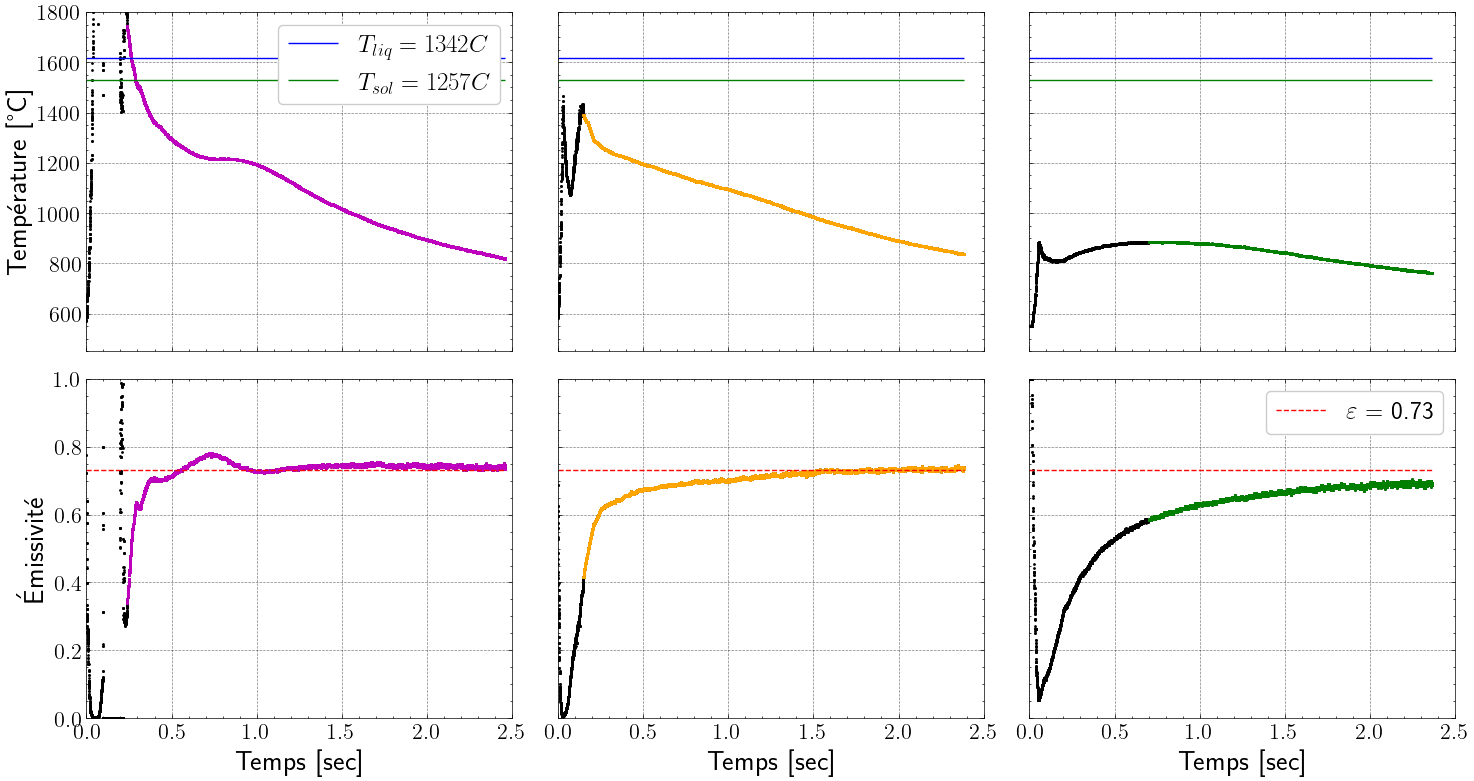

In [7]:
cordon_selection = [11, 13, 15]

fig, axs = plt.subplots(2, len(cordon_selection), figsize=(15, 8), sharex='col', sharey='row')  # 2 lignes, 3 colonnes, partage x/y
for idx, cordon in enumerate(cordon_selection):
    low_boundary, high_boundary = boundaries_data_selection[cordon]
    TIME = DATA[cordon]['array time']
    TEMP2C = DATA[cordon]['array MAtemp2C']
    EPSILON = DATA[cordon]['array MAemissivity']
    MASK_COLOR = TIME > boundaries_data_color[cordon]

    # Tracer la température (ligne 1)
    axs[0, idx].scatter(TIME, TEMP2C, s=1, c='k')
    axs[0, idx].scatter(TIME[MASK_COLOR], TEMP2C[MASK_COLOR], s=1, color=colors_plots_cordon[cordon])
    axs[0, idx].hlines(y=T_LIQUIDUS, xmin=TIME[0], xmax=TIME[-1], colors='b', label=r'$T_{liq} = 1342 °C$')
    axs[0, idx].hlines(y=T_SOLIDUS, xmin=TIME[0], xmax=TIME[-1], colors='g', label=r'$T_{sol} = 1257 °C$')

    axs[1, idx].hlines(y=0.73, xmin=TIME[0], xmax=TIME[-1], color='r', ls='--', label=r'$\varepsilon$ = 0.73')
    axs[0, idx].set_ylim(ymin=450, ymax=1800)
    
    if idx == 0:
        axs[0, idx].legend(fontsize=18)
    if idx == 2:
        axs[1, idx].legend(fontsize=18)
    
    if idx == 0:
        axs[0, idx].set_ylabel('Température [°C]', fontsize=20)
        axs[1, idx].set_ylabel('Émissivité', fontsize=20)

    # Tracer l'émissivité (ligne 2)
    axs[1, idx].scatter(TIME, EPSILON, c='k', s=1)
    axs[1, idx].scatter(TIME[MASK_COLOR], EPSILON[MASK_COLOR], color=colors_plots_cordon[cordon], s=1)
    axs[1, idx].set_ylim(0, 1)      
    
    axs[1, idx].set_xlabel('Temps [sec]', fontsize=20)

for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_xlim(0, 2.5)

fig.tight_layout()
plt.show()

#### Temperature - emissivity plan

In [8]:
iterations = [0, 0.8, 1.6]  # Profondeur en mm, avec 1.6 mm ajouté ici
iterations2 = [1.6, 2.6, 3.2]  # Profondeur en mm

# Inverser l'ordre pour que 0 soit en haut de la colorbar
iterations = sorted(iterations, reverse=True)
iterations2 = sorted(iterations2, reverse=True)

# Création d'un dégradé fluide de magenta à orange et d'orange à noir
scalars_magenta_to_orange = np.linspace(0, 1, 90)  # De magenta à orange
colors_magenta_to_orange = [interpolate_color((0.75, 0, 0.75), (1, .647, 0), scalar) for scalar in scalars_magenta_to_orange]

# Création d'un dégradé fluide d'orange à noir
scalars_orange_to_black = np.linspace(0, 1, 90)  # De orange à noir
colors_orange_to_black = interpolate_to_black((1, .647, 0), scalars_orange_to_black)
# colors_orange_to_green = [interpolate_color((1, .647, 0), (0, 0.5, 0), scalar) for scalar in scalars_orange_to_black]

# Combinaison des deux pour un dégradé fluide de magenta -> orange -> noir
colors_combined = colors_magenta_to_orange + colors_orange_to_black

# Création de la colormap avec la combinaison des couleurs
cm_smooth = LinearSegmentedColormap.from_list("magenta_to_black", colors_combined, N=200)
norm = Normalize(vmin=min(iterations), vmax=max(iterations2))  # Ajustement pour inclure la profondeur totale

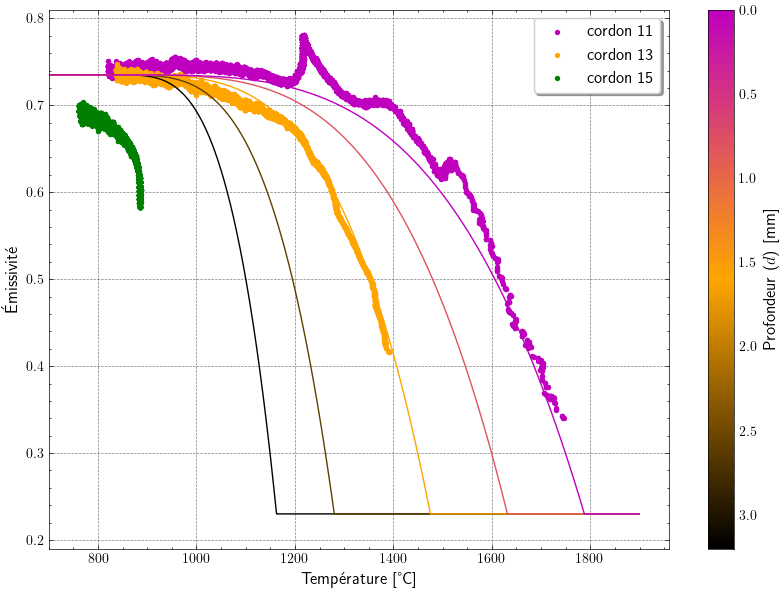

In [9]:
fig, ax1 = plt.subplots(1, 1, figsize=(10, 7))
temp_fake = np.arange(700, 1900, 0.5)

# Ajout des scatter plots pour les cordons 11 et 13
for idx, cordon in enumerate(cordon_selection):
    low_boundary, high_boundary = boundaries_data_selection[cordon]
    TIME = DATA[cordon]['array time']
    TEMP2C = DATA[cordon]['array MAtemp2C']
    EPSILON = DATA[cordon]['array MAemissivity']
    MASK_COLOR = TIME > boundaries_data_color[cordon]

    ax1.scatter(
        TEMP2C[MASK_COLOR], EPSILON[MASK_COLOR], 
        label=f'cordon {cordon}', color=colors_plots_cordon[cordon], s=8
        )

# Itérations pour les lignes avec la nouvelle loi
for cpt, d in enumerate(iterations2 + iterations[1:]):
    new_eps = wagner_inspired_emissivity(
        temperature=temp_fake,
        depth=d, 
        unit="mm", 
        block=False, 
        evolution="linear", 
        eps_min=0.23
    )

    ax1.plot(temp_fake, new_eps, c=cm_smooth(norm(d)))

# Ajustement de la colorbar avec inversion des valeurs (profondeur de 0 en haut)
sm = plt.cm.ScalarMappable(cmap=cm_smooth, norm=norm)
sm.set_array([])  # Nécessaire pour utiliser la colorbar
cbar = plt.colorbar(sm, ax=ax1)
cbar.set_label(r'Profondeur ($d$) [mm]', fontsize=12)
cbar.ax.tick_params(axis='y', which='major', labelsize=10)
cbar.ax.invert_yaxis()  # Inverse l'axe de la colorbar pour montrer 0 en haut

# Ajustements finaux
ax1.set_ylim(0.19, 0.81)
ax1.set_xlim(xmin=700)
ax1.tick_params(axis='both', which='major', labelsize=10)
plt.legend(['cordon 11', 'cordon 13', 'cordon 15'], loc='upper right', fontsize=12, frameon=True, shadow=True)
plt.xlabel('Température [°C]', fontsize=12)
plt.ylabel("Émissivité", fontsize=12)
# plt.savefig("../resultats/analytical_law.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

## Three thermal images

In [10]:
list_method = ['Uniform', 'First order', 'Wagner like']

information_targeted = {
        'thermal image':None,
        'Fourier thermal image':None,
        'shape quantification':None,
        'coordinates isotherm':None,
        'thermal gradient on isotherm':None,
        'solidification rate on isotherm':None,
        'hunt criteria coordinates':None,
        'classify growth mode':None
    }

DICT_STUDY_DATA = {key: information_targeted.copy() for key in list_method}

### Initialization stuff

#### Select reference image

In [11]:
int_id_cordon = 14
int_img_selected = params_clip[int_id_cordon]['snapshot']

array_raw_image = load_cred_array(
    path_image=os.path.join(data_path, f"CRED/data/layer_{int_id_cordon}/im_{int_img_selected}.npy")
)

#### Pyrometer wake
- The pyrometer is focused on a single, specific point on the wall. However, the melt pool moves along this wall during the deposition process. To simulate the pyrometer's effective recording when the melt pool passes through its observation point, we adjust the observation point in the image.

- Instead of capturing the melt pool as it naturally passes through the observation point, we shift the observation point in the image by the relative displacement speed. This adjustment mimics the pyrometer's recording as if the melt pool were actually moving through its fixed observation area.

- The relative path of the pyrometer created by this adjustment is called the "pyrometer wake."

- The concept of pyrometer wake relies on the assumption that the thermal field maintains a steady-state shape throughout the deposition of a single bead.

In [12]:
hauteur = int(0.8/FAC)  # Pyrometer spot size is 0.8 mm 
lim_sup_mm = 8.1
lim_sup = int((19.2-lim_sup_mm)/19.2*512 )

pyrometer_wake = np.zeros((LINES_CRED, COLUMNS_CRED, 4))
pyrometer_wake[lim_sup:lim_sup+hauteur,:,:]=1
pyrometer_wake[lim_sup:lim_sup+hauteur,:,3]=0.5

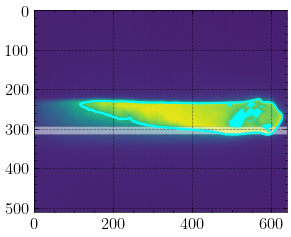

In [13]:
contour_level = 1e4

plt.imshow(np.flipud(array_raw_image))
plt.imshow(pyrometer_wake)
plt.contour(np.flipud(array_raw_image), levels=[contour_level], colors='cyan', linewidths=1.5)
plt.show()

#### Support array

In [14]:
# upper_limit: defined at the beginning of the notebook.
delay = params_clip[int_id_cordon]['delay']
upper_limit = params_clip[int_id_cordon]['upper limit px']
direction = int_id_cordon % 2 == 0

y_matrix_pos = (np.arange(0, 512) - upper_limit)*FAC
x_matrix_pos = (np.arange(639, -1, -1) if direction else np.arange(0, 640))*FAC/16.7

time_contribution, depth_contribution = np.meshgrid(
    x_matrix_pos, y_matrix_pos
)

mask_prof = np.zeros_like(depth_contribution, dtype=bool)
mask_prof[:upper_limit,:]=True  # True == unwanted values

if direction:
    x = 640 - int(delay * 16.7 / FAC)
else:
    x = int(delay * 16.7 / FAC)

ref_point = (x, int(upper_limit + hauteur/2))

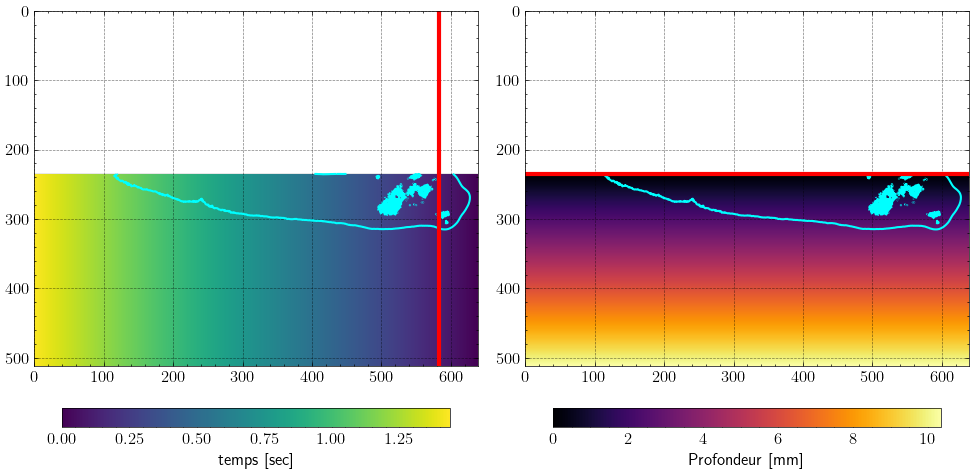

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

contour_level = 1e4
contour_masked = np.ma.masked_array(np.flipud(array_raw_image), mask_prof)

for ax in axes:
    ax.contour(contour_masked, levels=[contour_level], colors='cyan', linewidths=1.5)

im1 = axes[0].imshow(np.ma.masked_array(time_contribution, mask_prof), cmap='viridis', vmin=0, vmax=1.44)
# axes[0].set_title('time contribution')
if direction == True:
    axes[0].vlines(x=640-int(delay*16.7/FAC), ymin=0, ymax=512, color='r', lw=3)
else:
    axes[0].vlines(x=int(delay*16.7/FAC), ymin=0, ymax=512, color='r', lw=3)

# axes[0].axis('off')  # Désactiver les axes
cbar1 = fig.colorbar(im1, ax=axes[0], orientation='horizontal', fraction=0.046, pad=0.10)
cbar1.set_label('temps [sec]', fontsize=12)
cbar1.ax.tick_params(labelsize=12) 

im2 = axes[1].imshow(np.ma.masked_array(depth_contribution, mask_prof), cmap='inferno')
# axes[1].set_title('depth contribution')
axes[1].hlines(y=upper_limit, xmin=0, xmax=640, color='r', lw=3)
# axes[1].axis('off')  # Désactiver les axes
cbar2 = fig.colorbar(im2, ax=axes[1], orientation='horizontal', fraction=0.046, pad=0.10)
cbar2.set_label('Profondeur [mm]', fontsize=12)
cbar2.ax.tick_params(labelsize=12) 

for ax in axes.flatten():
    ax.set_xlim(0, 639)
    ax.set_ylim(511, 0)
    ax.tick_params(axis='both', which='major', labelsize=12)

# Afficher la figure
plt.tight_layout()
# plt.savefig("../resultats/time_and_depth_array_contribution.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

### Get images

#### Uniform emissivity field

In [16]:
# Emissivity field
uniform_emissivity_field = np.ones_like(array_raw_image) * 0.73

# Thermal image from homogenous emissivity field
thermal_image_uniform_emissivity_field = np.flipud(
        dl_to_thermo(
            dl_raw=array_raw_image,
            nuc_table=array_nuc,
            calibration_table=array_calibration,
            emissivity=uniform_emissivity_field
        )
)


#### First order heterogenous emissivity field

In [17]:
# Emissivity field
emissivity_field_first_order = first_order_emissivity(
    time=time_contribution,
    depth=depth_contribution,
    delay=delay,
    eps_non_oxy=0.23,
    eps_oxy=0.73,
    params_tau_evolve=time_constant_parameters
)

# Thermal image from heterogenous emissivity field
thermal_image_first_order_emissivity_field = np.flipud(
        dl_to_thermo(
            dl_raw=array_raw_image,
            nuc_table=array_nuc,
            calibration_table=array_calibration,
            emissivity=np.flipud(emissivity_field_first_order)
        )
)

#### Wagner inspired phenomenological law

In [18]:
No_iteration = 20
emissivity_starts = 0.73

# Initializing dictionary for local results
local_results={}

# Empty array for fixe point method
thermal_images = np.zeros((No_iteration+1, LINES_CRED, COLUMNS_CRED))
emissivity_maps = np.ones((No_iteration+1, LINES_CRED, COLUMNS_CRED))*emissivity_starts

# Load raw image for work
thermal_images[0]=dl_to_thermo(
    dl_raw=array_raw_image,
    nuc_table=array_nuc,
    calibration_table=array_calibration,
    emissivity=emissivity_starts
) - 273.15  # Celsius degree thermal maps

for iteration in range(1, No_iteration+1):

    # Update thermal maps
    current_thermo = np.copy(thermal_images[iteration-1])

    # Emissivity map from phenomenological law
    # emissivity_maps[iteration]=wagner_inspired_emissivity(
    #     temperature=current_thermo, 
    #     depth=np.flipud(depth_contribution), 
    #     unit='mm',
    #     block=False,
    #     evolution='linear',
    #     eps_min=0.23
    # )
    emissivity_maps[iteration]=wagner_inspired_emissivity(
        temperature=current_thermo, 
        depth=0, 
        unit='mm',
        block=False,
        evolution='linear',
        eps_min=0.23
    )

    # New thermal image from the phenomenological emissivity field
    thermal_images[iteration] = dl_to_thermo(
        dl_raw=array_raw_image,
        nuc_table=array_nuc,
        calibration_table=array_calibration,
        emissivity=emissivity_maps[iteration]
    ) - 273.15  # Celsius degree thermal maps

# Flip up-side down every images (Camera was up-side down during the recording)
thermal_all = np.asarray([np.flipud(thermal_images[i] + 273.15) for i in range(No_iteration+1)])
emissivity_all = np.asarray([np.flipud(emissivity_maps[i]) for i in range(No_iteration+1)])

local_results['thermal images']=thermal_all
local_results['emissivity maps']=emissivity_all

thermal_image_wagner_like_emissivity_field = thermal_all[No_iteration]
emissivity_field_oxidation_based = emissivity_all[No_iteration]

### Pyrometer sake: scalar data

##### Sake of pyrometer track through images

In [19]:
CAMERA_DATA_PYROMETER_SAKE = {}
list_of_images = [
    thermal_image_uniform_emissivity_field,
    thermal_image_first_order_emissivity_field,
    thermal_image_wagner_like_emissivity_field
]

list_of_emissivity_field = [
    uniform_emissivity_field,
    emissivity_field_first_order,
    emissivity_field_oxidation_based
]

for key, image, field in zip(DICT_STUDY_DATA.keys(), list_of_images, list_of_emissivity_field):

    temperature_C_evolution = [np.nanmean(image[lim_sup:lim_sup + 22, i:i + 22]-273.15) for i in range(COLUMNS_CRED)]
    temperature_C_evolution = np.asarray(temperature_C_evolution)

    emissivity_evolution = [np.nanmean(field[lim_sup:lim_sup + 22, i:i + 22]) for i in range(COLUMNS_CRED)]
    emissivity_evolution = np.asarray(emissivity_evolution)

    time_evolution = np.arange(temperature_C_evolution.size) / params_clip[int_id_cordon]['FPS estimate']

    CAMERA_DATA_PYROMETER_SAKE[key] = {
        'temperature [C]': temperature_C_evolution,
        'emissivity': emissivity_evolution,
        'time': time_evolution
    }

##### visualization

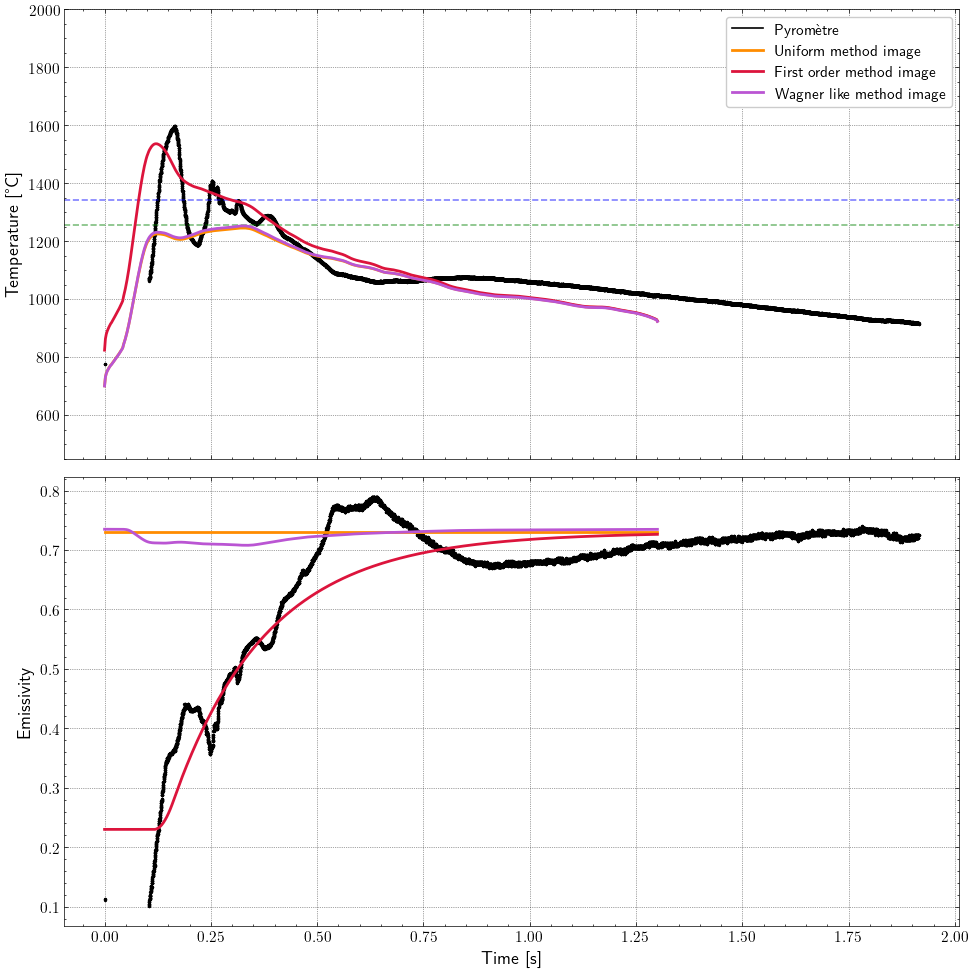

In [20]:
from matplotlib.lines import Line2D

list_format = ['darkorange', 'crimson', 'mediumorchid']
meta_data_pyro = {
    11 : 0.2,
    12 : 0.37,
    13 : 0.0,
    14 : 0.0,
    15 : 0.0,
    16 : 0.17,
}
# Deux lignes avec le même axe des abscisses
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 10))

mask_pyro = DATA[int_id_cordon]['array MAemissivity'] > 0.1
delay_pyro = meta_data_pyro[int_id_cordon]

# -------- Temperature --------
ax1.scatter(
    DATA[int_id_cordon]['array time'][mask_pyro] - delay_pyro, 
    DATA[int_id_cordon]['array MAtemp2C'][mask_pyro],
    s=2,
    c='k'
)
line_handles = [
    Line2D([0], [0], color='k', lw=1.2, label=f'Pyrometer temperature recorded'),
]

for idx, method in enumerate(CAMERA_DATA_PYROMETER_SAKE):
    temperature_on_map = np.flip(CAMERA_DATA_PYROMETER_SAKE[method]['temperature [C]']) if direction else CAMERA_DATA_PYROMETER_SAKE[method]['temperature [C]']
    ax1.plot(
        CAMERA_DATA_PYROMETER_SAKE[method]['time'],
        temperature_on_map,
        list_format[idx],
        label=f'{method} method image',
        linewidth=2
    )

# Solidus / Liquidus
ax1.axhline(T_SOLIDUS - 273.15, color='green', linestyle='--', linewidth=1.2, zorder=1, alpha=0.5)
ax1.axhline(T_LIQUIDUS - 273.15, color='blue', linestyle='--', linewidth=1.2, zorder=1, alpha=0.5)

# -------- Emissivity --------
ax2.scatter(
    DATA[int_id_cordon]['array time'][mask_pyro] - delay_pyro, 
    DATA[int_id_cordon]['array MAemissivity'][mask_pyro],
    label='Pyrometer temperature recorded',
    s=2,
    c='k'
)

for idx, method in enumerate(CAMERA_DATA_PYROMETER_SAKE):
    emissivity_on_filed = np.flip(CAMERA_DATA_PYROMETER_SAKE[method]['emissivity']) if direction else CAMERA_DATA_PYROMETER_SAKE[method]['emissivity']
    ax2.plot(
        CAMERA_DATA_PYROMETER_SAKE[method]['time'],
        emissivity_on_filed,
        list_format[idx],
        label=f'{method} emissivity',
        linewidth=2
    )

# -------- Légendes --------
# Température : courbes + lignes
# curve_handles, curve_labels = ax1.get_legend_handles_labels()
# line_handles = [
#     Line2D([0], [0], color='green', lw=1.2, label=f'Solidus ({T_SOLIDUS - 273.15:.0f} °C)'),
#     Line2D([0], [0], color='blue', lw=1.2, label=f'Liquidus ({T_LIQUIDUS - 273.15:.0f} °C)'),
# ]
# ax1.legend(curve_handles + line_handles, fontsize=11, loc='upper right')

# Émissivité : légende
curve_handles, curve_labels = ax1.get_legend_handles_labels()
ax1.legend([line_handles[0]] + curve_handles, ['Pyromètre'] + curve_labels, fontsize=11, loc='upper right')


# -------- Axes et labels --------
ax1.set_ylabel('Temperature [°C]', fontsize=13)
ax1.set_ylim(450, 2000)
# ax1.set_xlim(0, 1.5)
ax1.grid(True, linestyle=':', linewidth=0.5, alpha=0.7)

ax2.set_ylabel('Emissivity', fontsize=13)
# ax2.set_ylim(0, 1)  # À ajuster si besoin
ax2.set_xlabel('Time [s]', fontsize=13)
ax2.grid(True, linestyle=':', linewidth=0.5, alpha=0.7)

# Ticks
ax1.tick_params(axis='both', which='major', labelsize=11)
ax2.tick_params(axis='both', which='major', labelsize=11)

fig.tight_layout()
# fig.savefig(os.path.join(saving_path ,f"overlay_pyrometer_wake_{int_id_cordon}.png"), format='png', bbox_inches='tight')
plt.show()

### Set images

In [21]:
DICT_STUDY_DATA['Uniform']['thermal image'] = thermal_image_uniform_emissivity_field
DICT_STUDY_DATA['Uniform']['emissivity field'] = uniform_emissivity_field

DICT_STUDY_DATA['First order']['thermal image'] = thermal_image_first_order_emissivity_field
DICT_STUDY_DATA['First order']['emissivity field'] = emissivity_field_first_order

DICT_STUDY_DATA['Wagner like']['thermal image'] = thermal_image_wagner_like_emissivity_field
DICT_STUDY_DATA['Wagner like']['emissivity field'] = emissivity_field_oxidation_based

### Melt Poll Dynamics Calculation

In [22]:
crop_data=(200,0,250,639)

with open(
    os.path.join(saving_path ,f"MP_size_{int_id_cordon}.txt"), "w"
    ) as MP_dimensions:

    for key in list_method:

        working_image = DICT_STUDY_DATA[key]['thermal image']

        # Compute thermal gradient resolving an illness problem using Fourier transformation
        GradThermal = RegularizedThermalGradient(
            raw_image=working_image,
            crop_data=crop_data,
            harmonics_X=30,
            harmonics_Y=15,
            scale=FAC,
            manual_alpha=0.35,
            optimized=True
        )
            
        # Get the Fourier images rescaled into the field of view of the camera
        Fourier_image = GradThermal.get_Fourier_formulation_vectorized()
        resized_Fourier_image = GradThermal.resize_to_original(
            image_to_resize=np.ma.masked_array(Fourier_image, GradThermal.mask_filled)
        )

        # Quantify isotherm shape using a quarter of ellipsoid and get the thermal information on it
        isotherm_length, isotherm_depth, isotherm_coordinates, gradient_on_isotherm, \
            thermal_orientation_on_isotherm, solidification_rate_on_isotherm, hunt_criteria_coordinates = hunt_data_on_isotherm(
                working_image=working_image,
                direction=direction,
                T_target=T_SOLIDUS,
                reference_point=ref_point,
                norm_thermal_gradient=GradThermal.thermal_gradient_norm,
                orientation_thermal_gradient=GradThermal.thermal_gradient_orientation,
                save_path=False
            )
        
        # display_G_and_R_on_images(
        #     image_to_plot=working_image,
        #     T_target=T_SOLIDUS,
        #     hunt_coo=hunt_criteria_coordinates,
        #     filtered_gradient=gradient_on_isotherm,
        #     filtered_orientation=thermal_orientation_on_isotherm,
        #     crop_y_axis=(crop_data[0] + crop_data[2], crop_data[0]),
        #     scale_arrow=1,
        #     saving_path=os.path.join(saving_path, f'G_R_on_image_{int_id_cordon}_{key}.png')
        # )
        # Classify the growth mode according to the Hunt criterion for IN718
        list_growth_mode = classify_growth_mode(
            thermal_gradient_data=gradient_on_isotherm,
            solidification_rate_data=np.abs(solidification_rate_on_isotherm),
            power_fit_params=CET_IN718_fitting_parameters
        )

        # Set information
        DICT_STUDY_DATA[key]['Fourier thermal image'] = resized_Fourier_image
        DICT_STUDY_DATA[key]['shape quantification'] = (isotherm_length, isotherm_depth)
        DICT_STUDY_DATA[key]['coordinates isotherm'] = isotherm_coordinates
        DICT_STUDY_DATA[key]['thermal gradient on isotherm'] = gradient_on_isotherm
        DICT_STUDY_DATA[key]['thermal gradient orientation on isotherm'] = GradThermal.thermal_gradient_orientation[hunt_criteria_coordinates]
        DICT_STUDY_DATA[key]['solidification rate on isotherm'] = np.abs(solidification_rate_on_isotherm)
        DICT_STUDY_DATA[key]['hunt criteria coordinates'] = hunt_criteria_coordinates
        DICT_STUDY_DATA[key]['classify growth mode'] = list_growth_mode

        MP_dimensions.write(f"{key} {isotherm_length} {isotherm_depth}\n")

### Plot results - SOLIDUS

/tmp/ipykernel_38766/1997439034.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


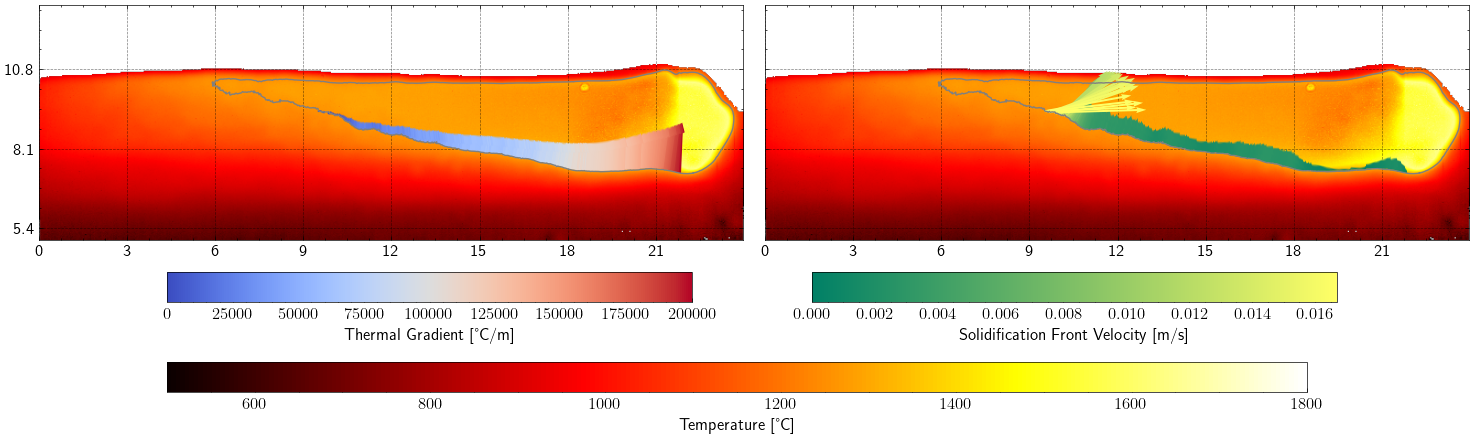

In [23]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

laser_speed = 0.0167

key = 'First order'
working_image = DICT_STUDY_DATA[key]['thermal image']
isotherm_coordinates = DICT_STUDY_DATA[key]['coordinates isotherm']
gradient_on_isotherm = DICT_STUDY_DATA[key]['thermal gradient on isotherm']
hunt_criteria_coordinates = DICT_STUDY_DATA[key]['hunt criteria coordinates']
thermal_orientation_on_isotherm = DICT_STUDY_DATA[key]['thermal gradient orientation on isotherm'] 

mask = (
    np.logical_or(
        DICT_STUDY_DATA['Uniform']['thermal image'] < 1200,
        np.isnan(DICT_STUDY_DATA['Uniform']['thermal image'])
    )
    & (depth_contribution < 1)
)
masked_image_to_plot = np.ma.masked_array(working_image, mask=mask)

contours = measure.find_contours(working_image, T_SOLIDUS)
largest_contour = max(contours, key=len)
largest_contour = np.array(largest_contour)
symmetrical_contour = largest_contour.copy()
symmetrical_contour[:, 0] = LINES_CRED - largest_contour[:, 0]  # Symmetry on Y-axis

# Contour and extent setup
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)

crop_min = params_clip[int_id_cordon]['crop low']
crop_max = params_clip[int_id_cordon]['crop high']

# Set ranges for colorbars
T_vmin, T_vmax = 500, 1800  # Temperatures [K]
G_vmin, G_vmax = 0, 2e5  # Thermal gradients [K/mm]
R_vmin, R_vmax = 0, laser_speed  # Solidification speed rates [m/s]

# Calculate gradient components
gradient_x = gradient_on_isotherm * np.cos(thermal_orientation_on_isotherm)
gradient_y = -gradient_on_isotherm * np.sin(thermal_orientation_on_isotherm)

# Calculate front speed components
front_speed_x = laser_speed * np.cos(thermal_orientation_on_isotherm)**2 
front_speed_y = -laser_speed * np.sin(thermal_orientation_on_isotherm)* np.cos(thermal_orientation_on_isotherm)
front_speed_rate = np.sqrt(front_speed_x**2 + front_speed_y**2)

# Create the figure with a simple layout: 1 column, 2 rows
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# First plot (Thermal gradient)
cax1 = ax1.imshow(masked_image_to_plot-273.15, cmap='hot', extent=extent, vmin=500, vmax=1800)
ax1.set_ylim(crop_min, crop_max)
quiver1 = ax1.quiver(
    (hunt_criteria_coordinates[1])*FAC, (LINES_CRED-hunt_criteria_coordinates[0])*FAC,
    gradient_x, gradient_y,
    gradient_on_isotherm,
    angles='xy', scale_units='xy', cmap='coolwarm',
)
ax1.plot(FAC * symmetrical_contour[:, 1], FAC * symmetrical_contour[:, 0], color='gray', linewidth=1)
ax1.set_xticks(xtick_pixels * FAC)
ax1.set_yticks(ytick_pixels * FAC)
ax1.set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])
ax1.set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])

# Axis labels and limits
# axes[0, col].set_xlabel('[mm]')
ax1.set_xlim(0, (COLUMNS_CRED - 1) * FAC)
ax1.set_ylim(0, (LINES_CRED - 1) * FAC)
ax1.set_ylim(crop_min, crop_max)

# Second plot (Cooling rate)
ratio = 1
cax2 = ax2.imshow(masked_image_to_plot-273.15, cmap='hot', extent=extent, vmin=500, vmax=1800)
ax2.set_ylim(crop_min, crop_max)
quiver2 = ax2.quiver(
    (hunt_criteria_coordinates[1])*FAC, 
    (LINES_CRED-hunt_criteria_coordinates[0])*FAC,
    front_speed_x*ratio, 
    front_speed_y*ratio,
    front_speed_rate,
    angles='xy', 
    scale_units='xy', 
    cmap='summer',
)
ax2.plot(FAC * symmetrical_contour[:, 1], FAC * symmetrical_contour[:, 0], color='gray', linewidth=1)
ax2.set_xticks(xtick_pixels * FAC)
ax2.set_yticks(ytick_pixels * FAC)
ax2.set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])
ax2.set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])

# Axis labels and limits
# axes[0, col].set_xlabel('[mm]')
ax2.set_xlim(0, (COLUMNS_CRED - 1) * FAC)
ax2.set_ylim(0, (LINES_CRED - 1) * FAC)
ax2.set_ylim(crop_min, crop_max)

# Adjust colorbar positions
# Vertical colorbar for temperature
cbar_ax_temp = fig.add_axes([0.12, 0.05, 0.76, 0.05])  # [left, bottom, width, height]
cbar_temp = fig.colorbar(cax1, cax=cbar_ax_temp, orientation='horizontal')
cbar_temp.set_label('Temperature [°C]', fontsize=12)
cbar_temp.ax.tick_params(labelsize=12)
# cbar_temp.ax.axvline(T_SOLIDUS-273.15, color='g', linestyle='-', linewidth=2)

# Horizontal colorbar for thermal gradient
cbar_ax_grad = fig.add_axes([0.12, 0.2, 0.35, 0.05])  # Close to the image
sm_grad = ScalarMappable(norm=Normalize(vmin=G_vmin, vmax=G_vmax), cmap='coolwarm')
cbar_grad = fig.colorbar(sm_grad, cax=cbar_ax_grad, orientation='horizontal')
cbar_grad.set_label('Thermal Gradient [°C/m]', fontsize=12)
cbar_grad.ax.tick_params(labelsize=12)

# Horizontal colorbar for cooling rate
cbar_ax_rate = fig.add_axes([0.55, 0.2, 0.35, 0.05])  # Close to the image
sm_rate = ScalarMappable(norm=Normalize(vmin=R_vmin, vmax=R_vmax), cmap='summer')
cbar_rate = fig.colorbar(sm_rate, cax=cbar_ax_rate, orientation='horizontal')
cbar_rate.set_label('Solidification Front Velocity [m/s]', fontsize=12)
cbar_rate.ax.tick_params(labelsize=12)

# ax1.tick_params(axis='both', which='both', bottom=False, left=True, labelleft=True, labelbottom=False)
# ax2.tick_params(axis='both', which='both', bottom=False, left=True, labelleft=True, labelbottom=False)

fig.tight_layout()
fig.savefig(os.path.join(saving_path ,f"Grad_and_speed_FO_{int_id_cordon}.pdf"), format='pdf', bbox_inches='tight')
plt.show()

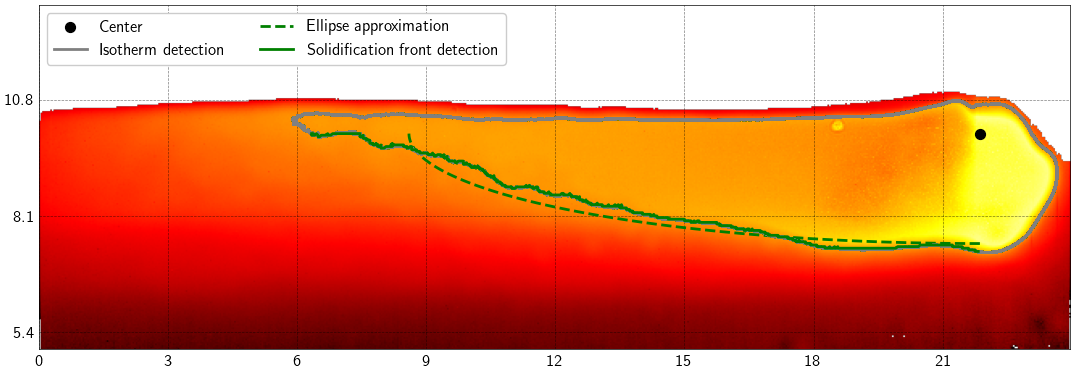

In [36]:
key = 'First order'
working_image = DICT_STUDY_DATA[key]['thermal image']
isotherm_coordinates = DICT_STUDY_DATA[key]['coordinates isotherm']
gradient_on_isotherm = DICT_STUDY_DATA[key]['thermal gradient on isotherm']
hunt_criteria_coordinates = DICT_STUDY_DATA[key]['hunt criteria coordinates']
thermal_orientation_on_isotherm = DICT_STUDY_DATA[key]['thermal gradient orientation on isotherm'] 
x_isotherm, y_isotherm = DICT_STUDY_DATA[key]['coordinates isotherm']


methods = ['Uniform', 'First order', 'Wagner like']
colors = {'Uniform': 'darkorange', 'First order': 'darkviolet', 'Wagner like': 'm'}

depths = {method: [] for method in methods}
lengths = {method: [] for method in methods}

with open(os.path.join(saving_path, f"MP_size_{int_id_cordon}.txt")) as file:
    data = file.readlines()
    for line in data:
        parts = line.strip().split()
        method = " ".join(parts[:-2])
        val1, val2 = map(float, parts[-2:])
        depth = min(val1, val2)
        length = max(val1, val2)
        if method in methods:
            depths[method].append(depth*FAC)
            lengths[method].append(length*FAC)

length_computed = lengths[key]
depths_computed = depths[key]

mask = (
    np.logical_or(
        DICT_STUDY_DATA['Uniform']['thermal image'] < 1200,
        np.isnan(DICT_STUDY_DATA['Uniform']['thermal image'])
    )
    & (depth_contribution < 1)
)
masked_image_to_plot = np.ma.masked_array(working_image, mask=mask)

contours = measure.find_contours(working_image, T_SOLIDUS)
largest_contour = max(contours, key=len)
largest_contour = np.array(largest_contour)
symmetrical_contour = largest_contour.copy()
symmetrical_contour[:, 0] = LINES_CRED - largest_contour[:, 0]  # Symmetry on Y-axis

# Contour and extent setup
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)

crop_min = params_clip[int_id_cordon]['crop low']
crop_max = params_clip[int_id_cordon]['crop high']

fig, ax1 = plt.subplots(figsize=(15, 4))

# Plot thermal image
masked_image_to_plot = np.ma.masked_array(working_image - 273.15, mask=mask)
im = ax1.imshow(masked_image_to_plot, cmap='hot', extent=extent, vmin=500, vmax=1800)


# Set ticks and labels
ax1.set_xticks(xtick_pixels * FAC)
ax1.set_yticks(ytick_pixels * FAC)
ax1.set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])
ax1.set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])

# Axis labels and limits
# axes[0, col].set_xlabel('[mm]')
ax1.set_xlim(0, (COLUMNS_CRED - 1) * FAC)
ax1.set_ylim(0, (LINES_CRED - 1) * FAC)
ax1.set_ylim(crop_min, crop_max)

delay = params_clip[int_id_cordon]['delay']
upper_limit = params_clip[int_id_cordon]['upper limit px']
direction = int_id_cordon % 2 == 0
if direction:
    x = 640 - int(delay * 16.7 / FAC)
else:
    x = int(delay * 16.7 / FAC)

Xc, Yc = (x, int(upper_limit + hauteur/2))
ax1.scatter(Xc*FAC, (LINES_CRED-Yc)*FAC, c='k', s=50, label='Center')
ax1.plot([],[], color='gray', linewidth=2, label='Isotherm detection')
# Ellipse
t = np.linspace(-np.pi/2, 0, 100)  # de 0 à 90 degrés
a = length_computed[0]  # demi-grand axe horizontal (mm)
b = depths_computed[0]  # demi-petit axe vertical (mm)
x_ellipse = Xc * FAC - a * np.cos(t)
y_ellipse = (LINES_CRED - Yc) * FAC + b * np.sin(t)
ax1.plot(
    x_ellipse, 
    y_ellipse, 
    linestyle='--', color='green', linewidth=2, 
    label='Ellipse approximation'
    )


# Plot contours
for contour in contours:
    ax1.plot(
        FAC * symmetrical_contour[:, 1], 
        FAC * symmetrical_contour[:, 0], 
        color='gray', linewidth=2,
        )
    
x_isotherm = LINES_CRED - x_isotherm

x = x_isotherm * FAC
y = y_isotherm * FAC
# Calcul des distances entre points consécutifs
dx = np.diff(x)
dy = np.diff(y)
distances = np.sqrt(dx**2 + dy**2)

# Seuil au-delà duquel on considère que c'est un saut à éviter
seuil = 2 

# On prépare les nouveaux tableaux avec rupture par NaN si saut trop grand
x_plot = [x[0]]
y_plot = [y[0]]

for i in range(1, len(x)):
    if distances[i - 1] > seuil:
        x_plot.append(np.nan)
        y_plot.append(np.nan)
    x_plot.append(x[i])
    y_plot.append(y[i])
ax1.plot(y_plot, x_plot, linestyle='-', color='green', lw=2, zorder=10, label='Solidification front detection')

ax1.tick_params(axis='both', which='both', length=0)

plt.legend(loc='upper left', ncols=2)
fig.tight_layout()
fig.savefig(os.path.join(saving_path ,f"MP_shape_FO_{int_id_cordon}.pdf"), format='pdf', bbox_inches='tight')
plt.show()

#### Plot Three images

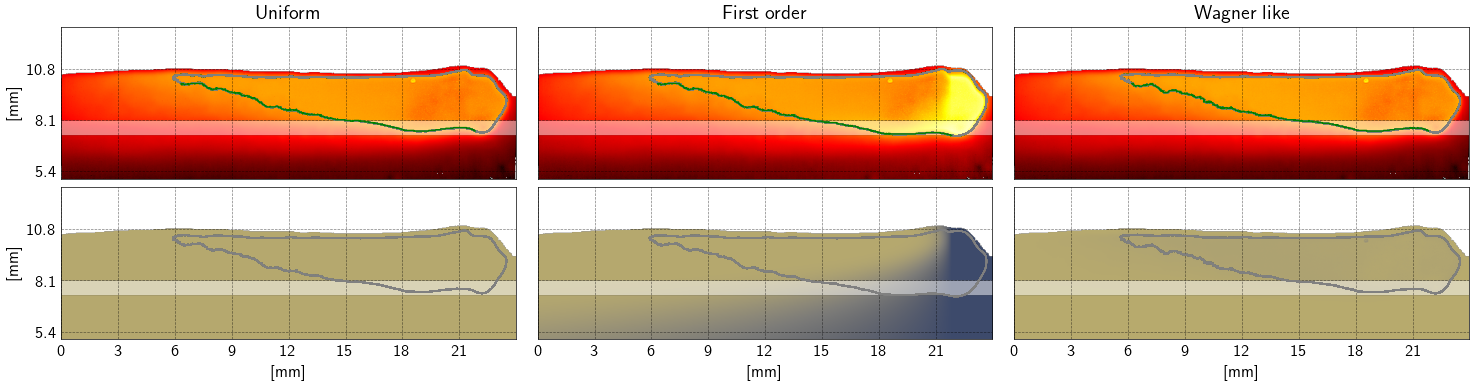

In [25]:
# Title
list_images = [DICT_STUDY_DATA[key]['thermal image'] for key in list_method]
list_field = [DICT_STUDY_DATA[key]['emissivity field'] for key in list_method]
mask = (
    np.logical_or(
        DICT_STUDY_DATA['Uniform']['thermal image'] < 1200,
        np.isnan(DICT_STUDY_DATA['Uniform']['thermal image'])
    )
    & (depth_contribution < 1)
)

# Contour and extent setup
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)

crop_min = params_clip[int_id_cordon]['crop low']
crop_max = params_clip[int_id_cordon]['crop high']

# Plot setup : 2 lignes (thermique + émissivité)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 4), sharex=True, sharey=True)

for col, method in enumerate(list_method):

    image_to_plot = DICT_STUDY_DATA[method]['thermal image']
    field_to_plot = DICT_STUDY_DATA[method]['emissivity field']
    x_isotherm, y_isotherm = DICT_STUDY_DATA[method]['coordinates isotherm']
    x_hunt_criteria, y_hunt_criteria = DICT_STUDY_DATA[method]['hunt criteria coordinates']

    # ----------- Line 1 : Thermal Maps -----------
    # Find contours
    contours = measure.find_contours(image_to_plot, T_SOLIDUS)
    largest_contour = max(contours, key=len)
    largest_contour = np.array(largest_contour)
    symmetrical_contour = largest_contour.copy()
    symmetrical_contour[:, 0] = LINES_CRED - largest_contour[:, 0]  # Symmetry on Y-axis

    # Plot thermal image
    masked_image_to_plot = np.ma.masked_array(image_to_plot - 273.15, mask=mask)
    im = axes[0, col].imshow(masked_image_to_plot, cmap='hot', extent=extent, vmin=500, vmax=1800)

    # Overlay pyrometer wake
    axes[0, col].imshow(pyrometer_wake, extent=extent, alpha=pyrometer_wake[..., 3])

    # Set ticks and labels
    axes[0, col].set_xticks(xtick_pixels * FAC)
    axes[0, col].set_yticks(ytick_pixels * FAC)
    axes[0, col].set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])
    axes[0, col].set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])

    # Axis labels and limits
    # axes[0, col].set_xlabel('[mm]')
    axes[0, col].set_xlim(0, (COLUMNS_CRED - 1) * FAC)
    axes[0, col].set_ylim(0, (LINES_CRED - 1) * FAC)
    axes[0, col].set_ylim(crop_min, crop_max)

    # Title
    axes[0, col].set_title(method)

    # Plot contours
    for contour in contours:
        axes[0, col].plot(FAC * symmetrical_contour[:, 1], FAC * symmetrical_contour[:, 0], color='gray', linewidth=1)
    
    x_isotherm = LINES_CRED - x_isotherm
    x_hunt_criteria = LINES_CRED - x_hunt_criteria

    x = x_isotherm * FAC
    y = y_isotherm * FAC
    # Calcul des distances entre points consécutifs
    dx = np.diff(x)
    dy = np.diff(y)
    distances = np.sqrt(dx**2 + dy**2)

    # Seuil au-delà duquel on considère que c'est un saut à éviter
    seuil = 2 

    # On prépare les nouveaux tableaux avec rupture par NaN si saut trop grand
    x_plot = [x[0]]
    y_plot = [y[0]]

    for i in range(1, len(x)):
        if distances[i - 1] > seuil:
            x_plot.append(np.nan)
            y_plot.append(np.nan)
        x_plot.append(x[i])
        y_plot.append(y[i])
    axes[0, col].plot(y_plot, x_plot, linestyle='-', color='green', zorder=10)

    axes[0, col].tick_params(axis='both', which='both', length=0)

    # ----------- Line 2 : Emissivity Field -----------
    masked_field_to_plot = np.ma.masked_array(field_to_plot, mask=mask)
    im_emiss = axes[1, col].imshow(masked_field_to_plot, cmap='cividis', extent=extent, vmin=0, vmax=1)

    # Overlay pyrometer wake (optionnel, commentable)
    axes[1, col].imshow(pyrometer_wake, extent=extent, alpha=pyrometer_wake[..., 3])

    # Ticks et format
    axes[1, col].set_xticks(xtick_pixels * FAC)
    axes[1, col].set_yticks(ytick_pixels * FAC)
    axes[1, col].set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])
    axes[1, col].set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])
    axes[1, col].tick_params(axis='both', which='both', length=0)

    # Axes labels
    axes[1, col].set_xlabel('[mm]')
    axes[1, col].set_xlim(0, (COLUMNS_CRED - 1) * FAC)
    axes[1, col].set_ylim(0, (LINES_CRED - 1) * FAC)
    axes[1, col].set_ylim(crop_min, crop_max)

    for contour in contours:
        axes[1, col].plot(FAC * symmetrical_contour[:, 1], FAC * symmetrical_contour[:, 0], color='gray', linewidth=1)

# ----------- Labels verticaux et colorbars -----------
axes[0, 0].set_ylabel('[mm]', fontsize=12)
axes[1, 0].set_ylabel('[mm]', fontsize=12)

# Colorbar température
# cbar_ax_temp = fig.add_axes([0.15, 0.53, 0.7, 0.02])
# cbar_temp = fig.colorbar(im, cax=cbar_ax_temp, orientation='horizontal')
# cbar_temp.set_label('Temperature [°C]')
# cbar_temp.ax.axvline(T_SOLIDUS - 273.15, color='green', linewidth=2)

# Colorbar emissivité
# cbar_ax_em = fig.add_axes([0.15, 0.08, 0.7, 0.02])
# cbar_em = fig.colorbar(im_emiss, cax=cbar_ax_em, orientation='horizontal')
# cbar_em.set_label('Emissivity')

fig.tight_layout()
# fig.savefig(os.path.join(saving_path ,f"TM_EF_{int_id_cordon}.pdf"), format='pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_38766/2050884293.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


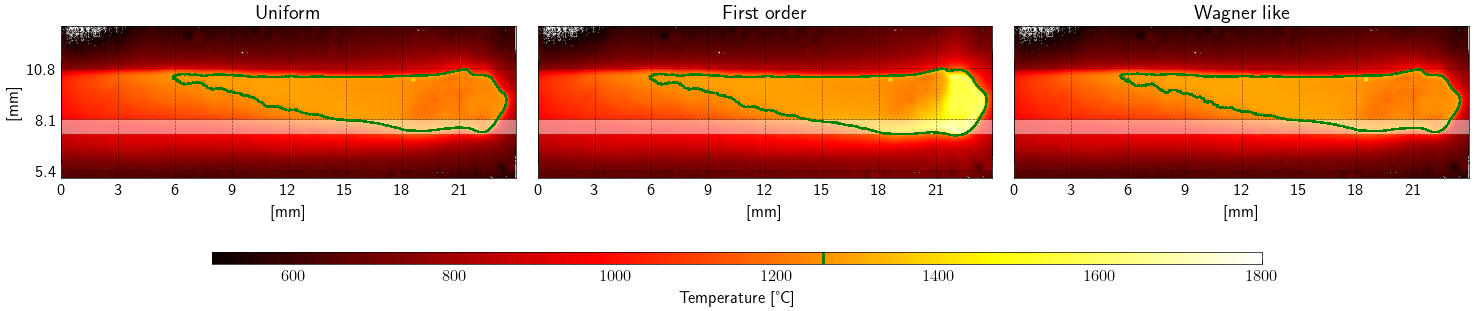

In [26]:
# Title
list_images = [DICT_STUDY_DATA[key]['thermal image'] for key in list_method]
list_field = [DICT_STUDY_DATA[key]['emissivity field'] for key in list_method]

# Contour and extent setup
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)


# Plot setup
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharex=True, sharey=True)

# Process and plot for each coefficient
for col, method in enumerate(list_method):

    image_to_plot = DICT_STUDY_DATA[method]['thermal image']

    # Find contours
    contours = measure.find_contours(image_to_plot, T_SOLIDUS)
    largest_contour = max(contours, key=len)
    largest_contour = np.array(largest_contour)
    symmetrical_contour = largest_contour.copy()
    symmetrical_contour[:, 0] = LINES_CRED - largest_contour[:, 0]  # Symmetry on Y-axis

    # Plot thermal image
    im = axes[col].imshow(image_to_plot - 273.15, cmap='hot', extent=extent, vmin=500, vmax=1800)

    # Overlay pyrometer wake
    axes[col].imshow(pyrometer_wake, extent=extent, alpha=pyrometer_wake[..., 3])

    # Set ticks and labels
    axes[col].set_xticks(xtick_pixels * FAC)
    axes[col].set_yticks(ytick_pixels * FAC)
    axes[col].set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])
    axes[col].set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])

    # Axis labels and limits
    axes[col].set_xlabel('[mm]')
    axes[col].set_xlim(0, (COLUMNS_CRED - 1) * FAC)
    axes[col].set_ylim(0, (LINES_CRED - 1) * FAC)

    # Crop limits
    crop_min = params_clip[int_id_cordon]['crop low']
    crop_max = params_clip[int_id_cordon]['crop high']
    axes[col].set_ylim(crop_min, crop_max)

    # Title
    axes[col].set_title(method)

    # Plot contours
    for contour in contours:
        axes[col].plot(FAC * symmetrical_contour[:, 1], FAC * symmetrical_contour[:, 0], color='green', linewidth=1)

    axes[col].tick_params(axis='both', which='both', length=0)

# Colorbar setup
axes[0].set_ylabel('[mm]')
cbar_ax = fig.add_axes([0.15, 0.23, 0.7, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Temperature [°C]')
cbar.ax.axvline(T_SOLIDUS-273.15, color='green', linewidth=2)

# Display plot
fig.tight_layout()
# fig.savefig(os.path.join(saving_path ,f"TM_{int_id_cordon}.pdf"), format='pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_38766/2043615156.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


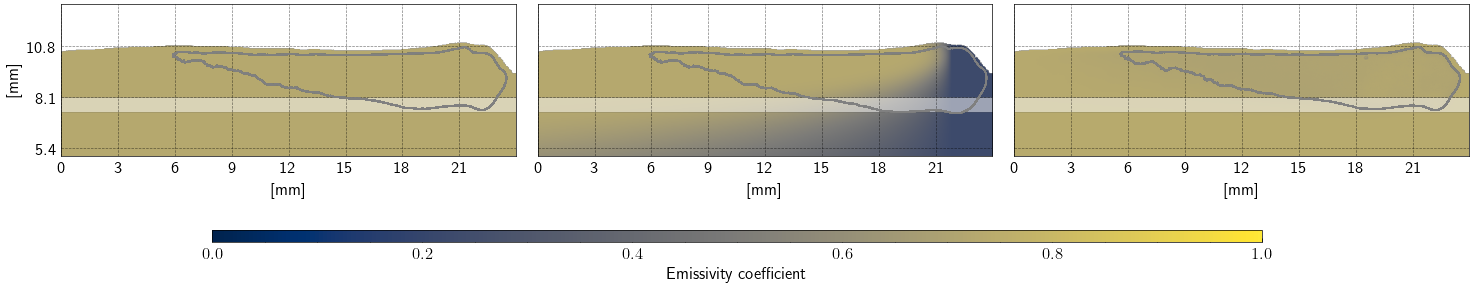

In [27]:
# Title
list_field = [DICT_STUDY_DATA[key]['emissivity field'] for key in list_method]

# Contour and extent setup
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)


# Plot setup
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharex=True, sharey=True)

# Process and plot for each coefficient
for col, method in enumerate(list_method):

    image_to_plot = DICT_STUDY_DATA[method]['thermal image']

    # Find contours
    contours = measure.find_contours(image_to_plot, T_SOLIDUS)
    largest_contour = max(contours, key=len)
    largest_contour = np.array(largest_contour)
    symmetrical_contour = largest_contour.copy()
    symmetrical_contour[:, 0] = LINES_CRED - largest_contour[:, 0]  # Symmetry on Y-axis

    field_to_plot = DICT_STUDY_DATA[method]['emissivity field']

    masked_field_to_plot = np.ma.masked_array(field_to_plot, mask=mask)
    im_emiss = axes[col].imshow(masked_field_to_plot, cmap='cividis', extent=extent, vmin=0, vmax=1)

    # Overlay pyrometer wake (optionnel, commentable)
    axes[col].imshow(pyrometer_wake, extent=extent, alpha=pyrometer_wake[..., 3])

    # Ticks et format
    axes[col].set_xticks(xtick_pixels * FAC)
    axes[col].set_yticks(ytick_pixels * FAC)
    axes[col].set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])
    axes[col].set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])
    axes[col].tick_params(axis='both', which='both', length=0)

    # Axes labels
    axes[col].set_xlabel('[mm]')
    axes[col].set_xlim(0, (COLUMNS_CRED - 1) * FAC)
    axes[col].set_ylim(0, (LINES_CRED - 1) * FAC)
    axes[col].set_ylim(crop_min, crop_max)

    for contour in contours:
        axes[col].plot(FAC * symmetrical_contour[:, 1], FAC * symmetrical_contour[:, 0], color='gray', linewidth=1)


# Colorbar setup
axes[0].set_ylabel('[mm]')
cbar_ax = fig.add_axes([0.15, 0.23, 0.7, 0.02])
cbar = fig.colorbar(im_emiss, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Emissivity coefficient')

# Display plot
fig.tight_layout()
# fig.savefig(os.path.join(saving_path ,f"EF_{int_id_cordon}.pdf"), format='pdf', bbox_inches='tight')
plt.show()

#### Hunt graphic

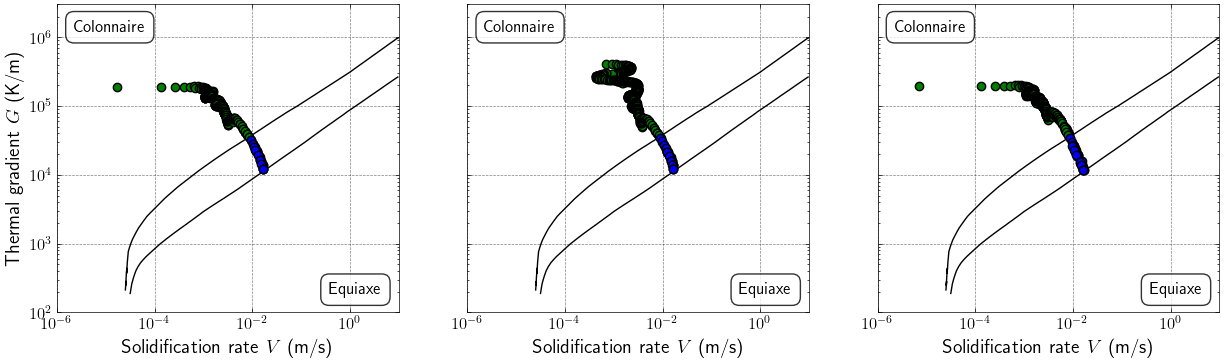

In [28]:

file_path = os.path.join(BASE_DIR, "TherMIFASOL/resources/CET_INCONEL")

V_col, G_col = np.loadtxt(os.path.join(file_path, "columnar_CET.txt")).T
V_equ, G_equ = np.loadtxt(os.path.join(file_path, "equiaxed_CET.txt")).T

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, method in zip(axes, list_method):

    classification = DICT_STUDY_DATA[method]['classify growth mode']
    G_data = DICT_STUDY_DATA[method]['thermal gradient on isotherm' ]
    R_data = np.abs(DICT_STUDY_DATA[method]['solidification rate on isotherm'])

    ax.loglog(V_col, G_col, label='Columnar to Equiaxed boundaries', c='k')
    ax.loglog(V_equ, G_equ, c='k')
    # Ajouter du texte en haut à gauche et en bas à droite
    ax.text(
        0.05, 0.95, 'Colonnaire', transform=ax.transAxes, fontsize=12, fontweight='bold',
        verticalalignment='top', horizontalalignment='left', bbox=dict(facecolor='white', boxstyle='round,pad=0.5', alpha=0.8))
    ax.text(
        0.95, 0.05, f'Equiaxe', transform=ax.transAxes, fontsize=12, fontweight='bold',
        verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='white', boxstyle='round,pad=0.5', alpha=0.8))

    # Plot the data points
    colors = ['g', 'b', 'r']
    for class_ in np.unique(classification):
        col = colors[class_]
        sc = ax.scatter(
            R_data[classification==class_], 
            G_data[classification==class_], 
            c=col, edgecolor='k', zorder=3
            )
    
    # ax.set_title(method)
    ax.set_xlim(1e-6, 1e1)
    ax.set_ylim(1e2, 3e6)
    ax.set_xlabel('Solidification rate $V$ (m/s)', fontsize=14)
    if method == 'Uniform':
        ax.set_ylabel('Thermal gradient $G$ (K/m)', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)

    # Display the grid
    ax.grid(True, which="major", ls="--")

fig.savefig(os.path.join(saving_path ,f"Hunt_id{int_id_cordon}.pdf"), format='pdf', bbox_inches='tight')
plt.show()

## Melt Pool Size

In [11]:
methods = ['Uniform', 'First order', 'Wagner like']
colors = {'Uniform': 'darkorange', 'First order': 'darkviolet', 'Wagner like': 'm'}

depths = {method: [] for method in methods}
lengths = {method: [] for method in methods}

for id_cordon in list_relevant_beads:
    with open(os.path.join(saving_path, f"MP_size_{id_cordon}.txt")) as file:
        data = file.readlines()
        for line in data:
            parts = line.strip().split()
            method = " ".join(parts[:-2])
            val1, val2 = map(float, parts[-2:])
            depth = min(val1, val2)
            length = max(val1, val2)
            if method in methods:
                depths[method].append(depth*FAC)
                lengths[method].append(length*FAC)


relative error len FO: [2.51028764 1.2615528  2.32492173 0.97428872 2.42552423 1.17020649] %
relative error len WL: [ 3.48241257  5.36069012 12.1691009   6.16910178  8.17241299  7.1764547 ] %
relative error dep FO: [15.624677    8.37792875 14.82293561  7.89725945 16.45703368  8.28608981] %
relative error dep WL: [ 1.63938361 26.66780253  9.98957914 22.12851671 11.97043871 26.14439394] %


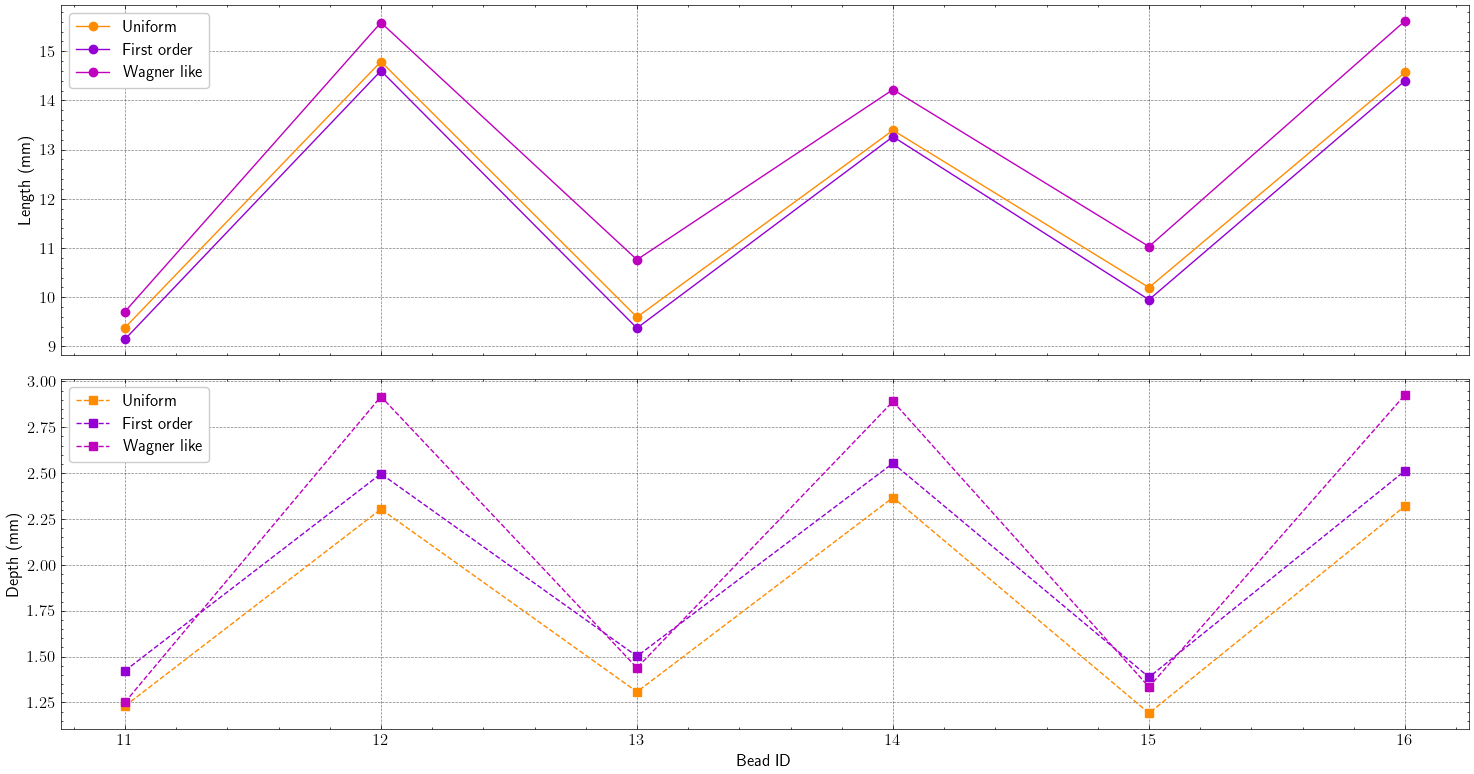

In [12]:
len_Fo = 100*np.abs(np.asarray(lengths['Uniform']) - np.asarray(lengths['First order']))/np.asarray(lengths['Uniform'])
len_WL = 100*np.abs(np.asarray(lengths['Uniform']) - np.asarray(lengths['Wagner like']))/np.asarray(lengths['Uniform'])

dep_Fo = 100*np.abs(np.asarray(depths['Uniform']) - np.asarray(depths['First order']))/np.asarray(depths['Uniform'])
dep_WL = 100*np.abs(np.asarray(depths['Uniform']) - np.asarray(depths['Wagner like']))/np.asarray(depths['Uniform'])

print(f"relative error len FO: {len_Fo} %")
print(f"relative error len WL: {len_WL} %")
print(f"relative error dep FO: {dep_Fo} %")
print(f"relative error dep WL: {dep_WL} %")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Longueurs
for method in methods:
    ax1.plot(list_relevant_beads, lengths[method], 'o-', label=method, color=colors[method])
ax1.set_ylabel("Length (mm)")
# ax1.set_title("Melt Pool Length per Bead")
ax1.legend()
ax1.grid(True)

# Profondeurs
for method in methods:
    ax2.plot(list_relevant_beads, depths[method], 's--', label=method, color=colors[method])
ax2.set_ylabel("Depth (mm)")
ax2.set_xlabel("Bead ID")
# ax2.set_title("Melt Pool Depth per Bead")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
fig.savefig(os.path.join(saving_path ,f"MP_geometry.pdf"), format='pdf', bbox_inches='tight')
plt.show()

# Archive

### Plot results - T Target

In [ ]:
DICT_STUDY_DATA_T_target = {key: information_targeted.copy() for key in list_method}
alpha=0.5
col_isotherm = 'm'
T_TARGET = T_SOLIDUS + (T_LIQUIDUS - T_SOLIDUS)*alpha
print(f"Solidus = {T_SOLIDUS} K\nLiquidus = {T_LIQUIDUS} K\nT target = {T_TARGET} K")

Solidus = 1530.15 K
Liquidus = 1615.15 K
T target = 1572.65 K


#### Plot three images

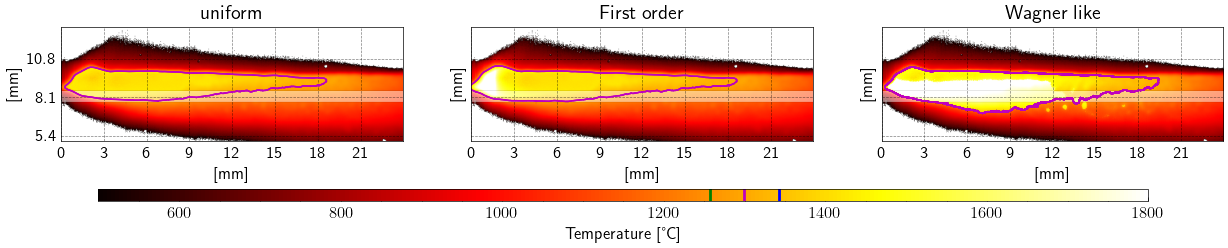

In [ ]:
# Title
list_images = [DICT_STUDY_DATA[key]['thermal image'] for key in list_method]

# Contour and extent setup
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)


# Plot setup
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharex=True, sharey=True)

# Process and plot for each coefficient
for col, method in enumerate(list_method):

    image_to_plot = DICT_STUDY_DATA[method]['thermal image']

    # Find contours
    contours = measure.find_contours(image_to_plot, T_TARGET)
    largest_contour = max(contours, key=len)
    largest_contour = np.array(largest_contour)
    symmetrical_contour = largest_contour.copy()
    symmetrical_contour[:, 0] = LINES_CRED - largest_contour[:, 0]  # Symmetry on Y-axis

    # Plot thermal image
    im = axes[col].imshow(image_to_plot - 273.15, cmap='hot', extent=extent, vmin=500, vmax=1800)

    # Overlay pyrometer wake
    axes[col].imshow(pyrometer_wake, extent=extent, alpha=pyrometer_wake[..., 3])

    # Set ticks and labels
    axes[col].set_xticks(xtick_pixels * FAC)
    axes[col].set_yticks(ytick_pixels * FAC)
    axes[col].set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])
    axes[col].set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])

    # Axis labels and limits
    axes[col].set_xlabel('[mm]')
    axes[col].set_ylabel('[mm]')
    axes[col].set_xlim(0, (COLUMNS_CRED - 1) * FAC)
    axes[col].set_ylim(0, (LINES_CRED - 1) * FAC)

    # Crop limits
    crop_min = params_clip[int_id_cordon]['crop low']
    crop_max = params_clip[int_id_cordon]['crop high']
    axes[col].set_ylim(crop_min, crop_max)

    # Title
    axes[col].set_title(method)

    # Plot contours
    for contour in contours:
        axes[col].plot(FAC * symmetrical_contour[:, 1], FAC * symmetrical_contour[:, 0], color=col_isotherm, linewidth=1)

    axes[col].tick_params(axis='both', which='both', length=0)

# Colorbar setup
cbar_ax = fig.add_axes([0.15, 0.3, 0.7, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Temperature [°C]')
cbar.ax.axvline(T_TARGET-273.15, color=col_isotherm, linewidth=2)
cbar.ax.axvline(T_LIQUIDUS-273.15, color='b', linewidth=2)
cbar.ax.axvline(T_SOLIDUS-273.15, color='g', linewidth=2)

# Display plot
plt.show()

In [ ]:
for key in list_method:

    working_image = DICT_STUDY_DATA[key]['thermal image']
    DICT_STUDY_DATA_T_target[key]['thermal image'] = working_image

    # Compute thermal gradient resolving an illness problem using Fourier transformation
    GradThermal = RegularizedThermalGradient(
        raw_image=working_image,
        crop_data=(200,0,200,639),
        harmonics_X=30,
        harmonics_Y=15,
        scale=FAC,
        manual_alpha=0.35,
        optimized=True
    )

    # Get the Fourier images rescaled into the field of view of the camera
    Fourier_image = GradThermal.get_Fourier_formulation_vectorized()
    resized_Fourier_image = GradThermal.resize_to_original(
        image_to_resize=np.ma.masked_array(Fourier_image, GradThermal.mask_filled)
    )

    # Quantify isotherm shape using a quarter of ellipsoid and get the thermal information on it
    ref_point = (60, 260)
    isotherm_length, isotherm_depth, isotherm_coordinates, gradient_on_isotherm, \
        thermal_orientation_on_isotherm, solidification_rate_on_isotherm, hunt_criteria_coordinates = hunt_data_on_isotherm(
            working_image=working_image,
            direction=direction,
            T_target=T_TARGET,
            reference_point=ref_point,
            norm_thermal_gradient=GradThermal.thermal_gradient_norm,
            orientation_thermal_gradient=GradThermal.thermal_gradient_orientation,
            save_path=False
        )

    # Classify the growth mode according to the Hunt criterion for IN718

    list_growth_mode = classify_growth_mode(
        thermal_gradient_data=gradient_on_isotherm,
        solidification_rate_data=np.abs(solidification_rate_on_isotherm),
        power_fit_params=CET_IN718_fitting_parameters
    )

    # Set information
    DICT_STUDY_DATA_T_target[key]['Fourier thermal image'] = resized_Fourier_image
    DICT_STUDY_DATA_T_target[key]['shape quantification'] = (isotherm_length, isotherm_depth)
    DICT_STUDY_DATA_T_target[key]['coordinates isotherm'] = isotherm_coordinates
    DICT_STUDY_DATA_T_target[key]['thermal gradient on isotherm'] = gradient_on_isotherm
    DICT_STUDY_DATA_T_target[key]['thermal gradient orientation on isotherm'] = GradThermal.thermal_gradient_orientation[hunt_criteria_coordinates]
    DICT_STUDY_DATA_T_target[key]['solidification rate on isotherm'] = np.abs(solidification_rate_on_isotherm)
    DICT_STUDY_DATA_T_target[key]['hunt criteria coordinates'] = hunt_criteria_coordinates
    DICT_STUDY_DATA_T_target[key]['classify growth mode'] = list_growth_mode

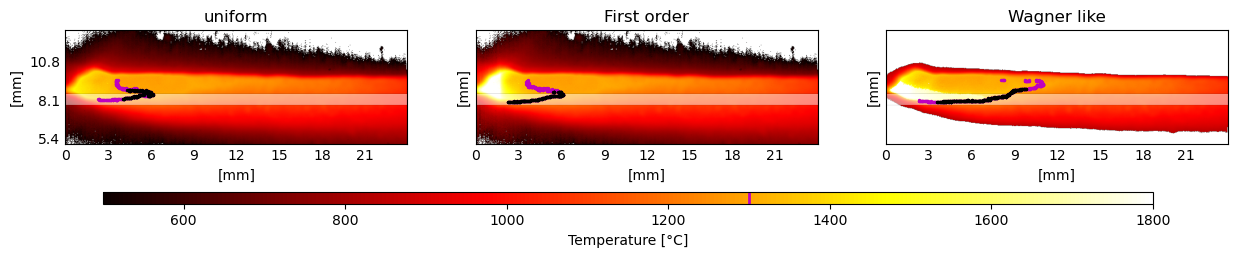

In [ ]:
# Contour and extent setup
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)


# Plot setup
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharex=True, sharey=True)

# Process and plot for each coefficient
for col, method in enumerate(list_method):

    image_to_plot = DICT_STUDY_DATA_T_target[method]['thermal image']
    image_OG = DICT_STUDY_DATA_T_target[method]['Fourier thermal image']
    x_isotherm, y_isotherm = DICT_STUDY_DATA_T_target[method]['coordinates isotherm']
    x_hunt_criteria, y_hunt_criteria = DICT_STUDY_DATA_T_target[method]['hunt criteria coordinates']

    x_isotherm = LINES_CRED - x_isotherm
    x_hunt_criteria = LINES_CRED - x_hunt_criteria

    # Plot thermal image
    im = axes[col].imshow(image_to_plot - 273.15, cmap='hot', extent=extent, vmin=500, vmax=1800)

    # Overlay pyrometer wake
    axes[col].imshow(pyrometer_wake, extent=extent, alpha=pyrometer_wake[..., 3])

    # Set ticks and labels
    axes[col].set_xticks(xtick_pixels * FAC)
    axes[col].set_yticks(ytick_pixels * FAC)
    axes[col].set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])
    axes[col].set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])

    # Axis labels and limits
    axes[col].set_xlabel('[mm]')
    axes[col].set_ylabel('[mm]')
    axes[col].set_xlim(0, (COLUMNS_CRED - 1) * FAC)
    axes[col].set_ylim(0, (LINES_CRED - 1) * FAC)

    # Crop limits
    crop_min = params_clip[int_id_cordon]['crop low']
    crop_max = params_clip[int_id_cordon]['crop high']
    axes[col].set_ylim(crop_min, crop_max)

    # Title
    axes[col].set_title(method)

    # Plot contours
    axes[col].scatter(y_isotherm*FAC, x_isotherm*FAC, color=col_isotherm, s=2)
    axes[col].scatter(y_hunt_criteria*FAC, x_hunt_criteria*FAC, color='k', s=2)

    axes[col].tick_params(axis='both', which='both', length=0)

# Colorbar setup
cbar_ax = fig.add_axes([0.15, 0.3, 0.7, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Temperature [°C]')
cbar.ax.axvline(T_TARGET-273.15, color=col_isotherm, linewidth=2)

# Display plot
plt.show()

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def display_G_and_R_on_images(image_to_plot: np.ndarray, T_target:float, hunt_coo:tuple, filtered_gradient: np.ndarray,
                              filtered_orientation: np.ndarray, crop_y_axis:tuple, laser_speed: float = 0.0167) -> None:
    """
    Display thermal gradient and solidification front velocity on images.

    Args:
        image_to_plot (np.ndarray): The image to plot.
        T_target (float): The target temperature for finding the isotherm.
        hunt_coo (tuple): The coordinates for the hunt data.
        filtered_gradient (np.ndarray): The filtered thermal gradient norm.
        filtered_orientation (np.ndarray): The filtered thermal gradient orientation.
        crop_y_axis (tuple): bottom and top limits for imshow cropping
        laser_speed (float): The laser speed in m/s.

    Returns:
        None
    """
    crop_min, crop_max = crop_y_axis
    # Set ranges for colorbars
    T_vmin, T_vmax = 500, 1800  # Temperatures [K]
    G_vmin, G_vmax = 0, 2e5  # Thermal gradients [K/mm]
    R_vmin, R_vmax = 0, laser_speed  # Solidification speed rates [m/s]

    # Calculate gradient components
    gradient_x = filtered_gradient * np.cos(filtered_orientation)
    gradient_y = filtered_gradient * np.sin(filtered_orientation)

    # Calculate front speed components
    front_speed_x = laser_speed * np.cos(filtered_orientation)
    front_speed_y = laser_speed * np.sin(filtered_orientation)

    # Normalize the front speed for color mapping
    front_speed_norm = np.sqrt(front_speed_x**2 + front_speed_y**2)
    norm_R = Normalize(vmin=R_vmin, vmax=R_vmax)

    # Create the figure with a simple layout: 1 column, 2 rows
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), constrained_layout=False)
    fig.subplots_adjust(hspace=0)

    # First plot (Thermal gradient)
    cax1 = ax1.imshow(image_to_plot, cmap='gray', vmin=T_vmin, vmax=T_vmax)
    ax1.set_ylim(crop_min, crop_max)
    quiver1 = ax1.quiver(
        hunt_coo[1], hunt_coo[0],
        gradient_x, gradient_y,
        filtered_gradient,
        alpha=0.2,
        angles='xy', scale_units='xy', scale=1000, cmap='coolwarm'
    )
    ax1.scatter(hunt_coo[1], hunt_coo[0], s=1, c='g')
    ax1.tick_params(axis='both', which='major', labelsize=12)

    # Second plot (Cooling rate)
    cax2 = ax2.imshow(image_to_plot, cmap='gray', vmin=T_vmin, vmax=T_vmax)
    ax2.set_ylim(crop_min, crop_max)
    quiver2 = ax2.quiver(
        hunt_coo[1], hunt_coo[0],
        front_speed_x, front_speed_y,
        np.abs(front_speed_x),
        alpha=0.2,
        angles='xy', scale_units='xy', scale=0.0005, cmap='plasma'
    )
    ax2.scatter(hunt_coo[1], hunt_coo[0], s=1, c='g')
    ax2.tick_params(axis='both', which='major', labelsize=12)

    # Adjust colorbar positions
    # Vertical colorbar for temperature
    cbar_ax_temp = fig.add_axes([0.98, 0.15, 0.02, 0.6])  # [left, bottom, width, height]
    cbar_temp = fig.colorbar(cax1, cax=cbar_ax_temp, orientation='vertical')
    cbar_temp.set_label('Temperature [K]', fontsize=12)
    cbar_temp.ax.tick_params(labelsize=12)
    cbar_temp.ax.axhline(T_target, color='g', linestyle='-', linewidth=2)

    # Horizontal colorbar for thermal gradient
    cbar_ax_grad = fig.add_axes([0.15, 0.54, 0.7, 0.02])  # Close to the image
    sm_grad = ScalarMappable(norm=Normalize(vmin=G_vmin, vmax=G_vmax), cmap='coolwarm')
    cbar_grad = fig.colorbar(sm_grad, cax=cbar_ax_grad, orientation='horizontal')
    cbar_grad.set_label('Thermal Gradient [K/m]', fontsize=12)
    cbar_grad.ax.tick_params(labelsize=12)

    # Horizontal colorbar for cooling rate
    cbar_ax_rate = fig.add_axes([0.15, 0.15, 0.7, 0.02])  # Close to the image
    sm_rate = ScalarMappable(norm=norm_R, cmap='plasma')
    cbar_rate = fig.colorbar(sm_rate, cax=cbar_ax_rate, orientation='horizontal')
    cbar_rate.set_label('Solidification Front Velocity [m/s]', fontsize=12)
    cbar_rate.ax.tick_params(labelsize=12)

    ax1.tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False, labelbottom=False)
    ax2.tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False, labelbottom=False)

    # Save the figure
    plt.show()



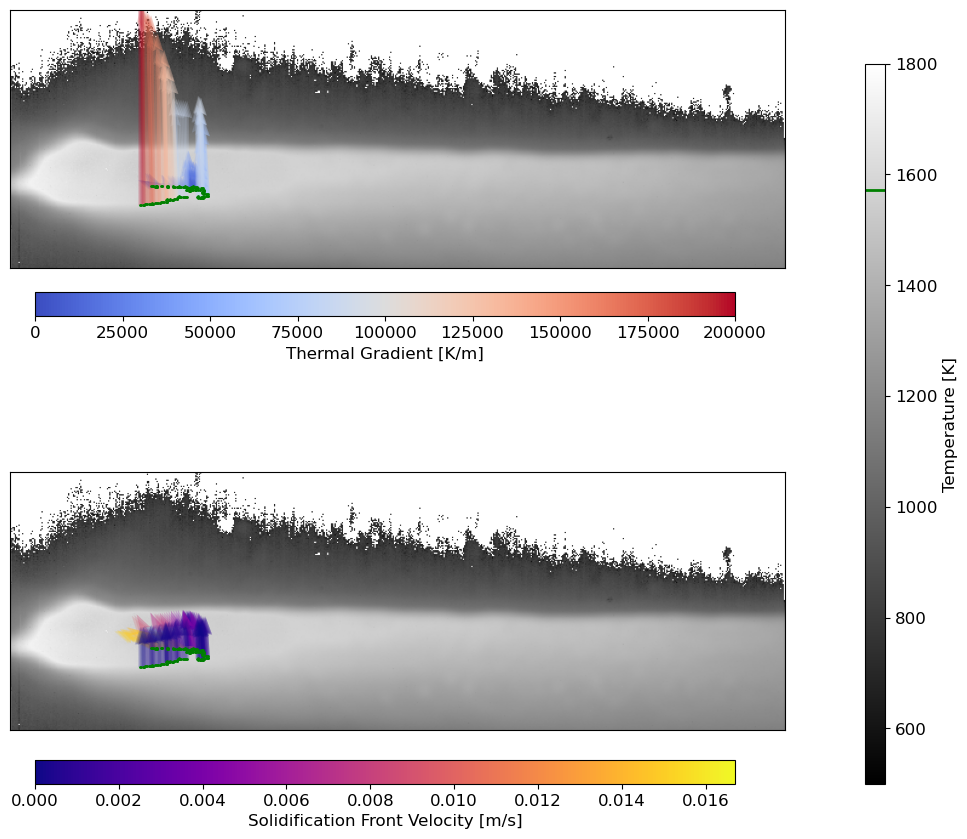

In [ ]:
method = 'uniform'
display_G_and_R_on_images(
    image_to_plot=DICT_STUDY_DATA_T_target[method]['thermal image'],
    T_target=T_TARGET,
    hunt_coo=DICT_STUDY_DATA_T_target[method]['hunt criteria coordinates'],
    filtered_gradient=DICT_STUDY_DATA_T_target[method]['thermal gradient on isotherm'],
    filtered_orientation=DICT_STUDY_DATA_T_target[method]['thermal gradient orientation on isotherm'],
    crop_y_axis=(params_clip[int_id_cordon]['crop high']/FAC, params_clip[int_id_cordon]['crop low']/FAC) 
)

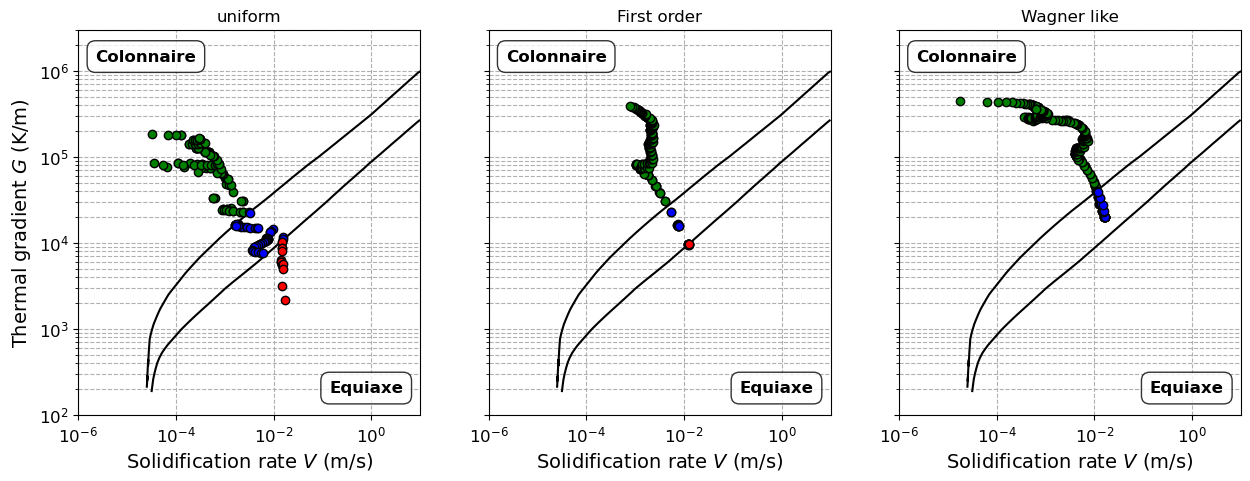

In [ ]:
path_data = "/media/dolle/Extreme SSD/DATA_MIFASOL_DOLLE/MIFASOL_project/data/CET_INCONEL"
V_col, G_col = np.loadtxt(f"{path_data}/columnar_CET.txt").T
V_equ, G_equ = np.loadtxt(f"{path_data}/equiaxed_CET.txt").T

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, method in zip(axes, list_method):

    classification = DICT_STUDY_DATA_T_target[method]['classify growth mode']
    G_data = DICT_STUDY_DATA_T_target[method]['thermal gradient on isotherm' ]
    R_data = np.abs(DICT_STUDY_DATA_T_target[method]['solidification rate on isotherm'])

    ax.loglog(V_col, G_col, label='Columnar to Equiaxed boundaries', c='k')
    ax.loglog(V_equ, G_equ, c='k')
    # Ajouter du texte en haut à gauche et en bas à droite
    ax.text(
        0.05, 0.95, 'Colonnaire', transform=ax.transAxes, fontsize=12, fontweight='bold',
        verticalalignment='top', horizontalalignment='left', bbox=dict(facecolor='white', boxstyle='round,pad=0.5', alpha=0.8))
    ax.text(
        0.95, 0.05, f'Equiaxe', transform=ax.transAxes, fontsize=12, fontweight='bold',
        verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='white', boxstyle='round,pad=0.5', alpha=0.8))

    # Plot the data points
    colors = ['g', 'b', 'r']
    for class_ in np.unique(classification):
        col = colors[class_]
        sc = ax.scatter(
            R_data[classification==class_], 
            G_data[classification==class_], 
            c=col, edgecolor='k', zorder=3
            )
    
    ax.set_title(method)
    ax.set_xlim(1e-6, 1e1)
    ax.set_ylim(1e2, 3e6)
    ax.set_xlabel('Solidification rate $V$ (m/s)', fontsize=14)
    if method == 'uniform':
        ax.set_ylabel('Thermal gradient $G$ (K/m)', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)

    # Display the grid
    ax.grid(True, which="both", ls="--")

plt.show()